# Scikit-Learn: A Comprehensive Masterclass
### From First Principles to Production-Ready Machine Learning

---

**Instructor:** Kajola Gbenga - CEO Prodigy Training Hub  
**Audience:** Python-proficient learners entering machine learning  
**Library Version:** scikit-learn 1.7.0  

---

## Table of Contents

| # | Module | Topics |
|---|--------|--------|
| 1 | **Introduction & Ecosystem** | What is sklearn, installation, the sklearn API contract |
| 2 | **Data Loading & Built-in Datasets** | toy datasets, real-world datasets, `fetch_*`, `make_*` |
| 3 | **The Estimator API** | `fit`, `predict`, `transform`, `fit_transform` |
| 4 | **Preprocessing** | Scaling, encoding, imputation, discretization |
| 5 | **Feature Engineering** | Polynomial features, interaction terms, custom transformers |
| 6 | **Pipelines** | `Pipeline`, `ColumnTransformer`, chaining |
| 7 | **Model Selection** | Train/test split, cross-validation, stratification |
| 8 | **Supervised Learning — Regression** | Linear, Ridge, Lasso, ElasticNet, SVR, Ensemble |
| 9 | **Supervised Learning — Classification** | Logistic, SVM, KNN, Trees, Forests, Gradient Boosting |
| 10 | **Evaluation Metrics** | Regression & Classification metrics, confusion matrix, ROC |
| 11 | **Hyperparameter Tuning** | GridSearchCV, RandomizedSearchCV, HalvingGridSearchCV |
| 12 | **Unsupervised Learning** | KMeans, DBSCAN, Agglomerative, PCA, t-SNE, UMAP |
| 13 | **Dimensionality Reduction** | PCA, LDA, NMF, TruncatedSVD |
| 14 | **Feature Selection** | Filter, Wrapper, Embedded, RFE, SelectFromModel |
| 15 | **Imbalanced Classes** | class_weight, resampling strategies |
| 16 | **Model Persistence** | `joblib`, `pickle`, saving and loading |
| 17 | **Custom Estimators** | Building your own sklearn-compatible classes |
| 18 | **End-to-End Project** | Full pipeline on a real dataset |

---


## Module 1 — Introduction and the Scikit-Learn Ecosystem

### 1.1 What is Scikit-Learn?

Scikit-learn is the most widely used open-source machine learning library for Python.  
It is built on top of **NumPy**, **SciPy**, and **Matplotlib**, and provides:

- A consistent, minimal API for **supervised** and **unsupervised** learning
- Tools for **model selection**, **evaluation**, and **preprocessing**
- Production-ready implementations of classical ML algorithms

**Key design philosophy:**  
Every object in sklearn is an *estimator* — it exposes `.fit()`, and depending on its role also `.predict()` or `.transform()`. This uniformity is what makes sklearn powerful.

```
NumPy / SciPy / Matplotlib
        │
   scikit-learn
   ├── Estimators (models)
   ├── Transformers (preprocessing)
   ├── Pipelines (composition)
   └── Evaluation tools
```


In [512]:
# Verify installation and print version info
import sklearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import warnings
warnings.filterwarnings('ignore')

print(f"scikit-learn : {sklearn.__version__}")
print(f"numpy        : {np.__version__}")
print(f"pandas       : {pd.__version__}")
print(f"matplotlib   : {matplotlib.__version__}")


scikit-learn : 1.7.0
numpy        : 2.3.1
pandas       : 2.3.1
matplotlib   : 3.10.3


### 1.2 The Three Core Interfaces

| Interface | Methods | Used for |
|-----------|---------|----------|
| **Estimator** | `.fit(X, y)` | All models and transformers |
| **Predictor** | `.predict(X)`, `.predict_proba(X)` | Supervised models |
| **Transformer** | `.transform(X)`, `.fit_transform(X)` | Preprocessing, feature extraction |

These three interfaces compose together through **Pipelines**.


In [513]:
# Illustrate the three interfaces with a minimal example
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_regression

X, y = make_regression(n_samples=100, n_features=3, noise=10, random_state=42)

# Transformer interface
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)   # fit + transform in one step
print("Scaler mean_ (learned params):", scaler.mean_.round(3))

# Estimator + Predictor interface
model = LinearRegression()
model.fit(X_scaled, y)               # learn from data
y_pred = model.predict(X_scaled)     # make predictions

print("Model coef_:", model.coef_.round(3))
print("First 5 predictions:", y_pred[:5].round(2))


Scaler mean_ (learned params): [ 0.092  0.075 -0.183]
Model coef_: [23.239 81.933 18.313]
First 5 predictions: [ 14.02 -17.9  110.35 -76.38 -35.47]


## Module 2 — Data Loading and Built-in Datasets

### 2.1 Toy Datasets

Sklearn ships with small datasets for quick experimentation.  
They are loaded into a **Bunch** object — essentially a dictionary with attribute access.

| Dataset | `load_*` | Task | Rows | Features |
|---------|----------|------|------|---------|
| Iris | `load_iris()` | Classification | 150 | 4 |
| Wine | `load_wine()` | Classification | 178 | 13 |
| Breast Cancer | `load_breast_cancer()` | Binary classification | 569 | 30 |
| Boston / California | `fetch_california_housing()` | Regression | 20,640 | 8 |
| Diabetes | `load_diabetes()` | Regression | 442 | 10 |
| Digits | `load_digits()` | Multi-class | 1,797 | 64 |


In [514]:
from sklearn.datasets import (load_iris, load_wine, load_breast_cancer,
                              load_diabetes, load_digits)

# Load and explore the Iris dataset
iris = load_iris()

print("=== IRIS DATASET ===")
print("Type            :", type(iris))
print("Keys            :", list(iris.keys()))
print("Data shape      :", iris.data.shape)
print("Target shape    :", iris.target.shape)
print("Feature names   :", iris.feature_names)
print("Target names    :", iris.target_names)
print("\nFirst 5 rows:")
print(iris.data[:5])
print("First 5 targets:", iris.target[:5])


=== IRIS DATASET ===
Type            : <class 'sklearn.utils._bunch.Bunch'>
Keys            : ['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module']
Data shape      : (150, 4)
Target shape    : (150,)
Feature names   : ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names    : ['setosa' 'versicolor' 'virginica']

First 5 rows:
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
First 5 targets: [0 0 0 0 0]


In [515]:
# Convert to a pandas DataFrame for easier exploration
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

print(iris_df.head(10))
print("\nClass distribution:")
print(iris_df['species'].value_counts())
print("\nDescriptive stats:")
print(iris_df.describe().round(2))


   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   
5                5.4               3.9                1.7               0.4   
6                4.6               3.4                1.4               0.3   
7                5.0               3.4                1.5               0.2   
8                4.4               2.9                1.4               0.2   
9                4.9               3.1                1.5               0.1   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  
5  setosa  
6  setosa  
7  setosa  
8  setosa  
9  setosa 

### 2.2 Synthetic Dataset Generators

`make_*` functions generate custom datasets with known properties — ideal for teaching and debugging.


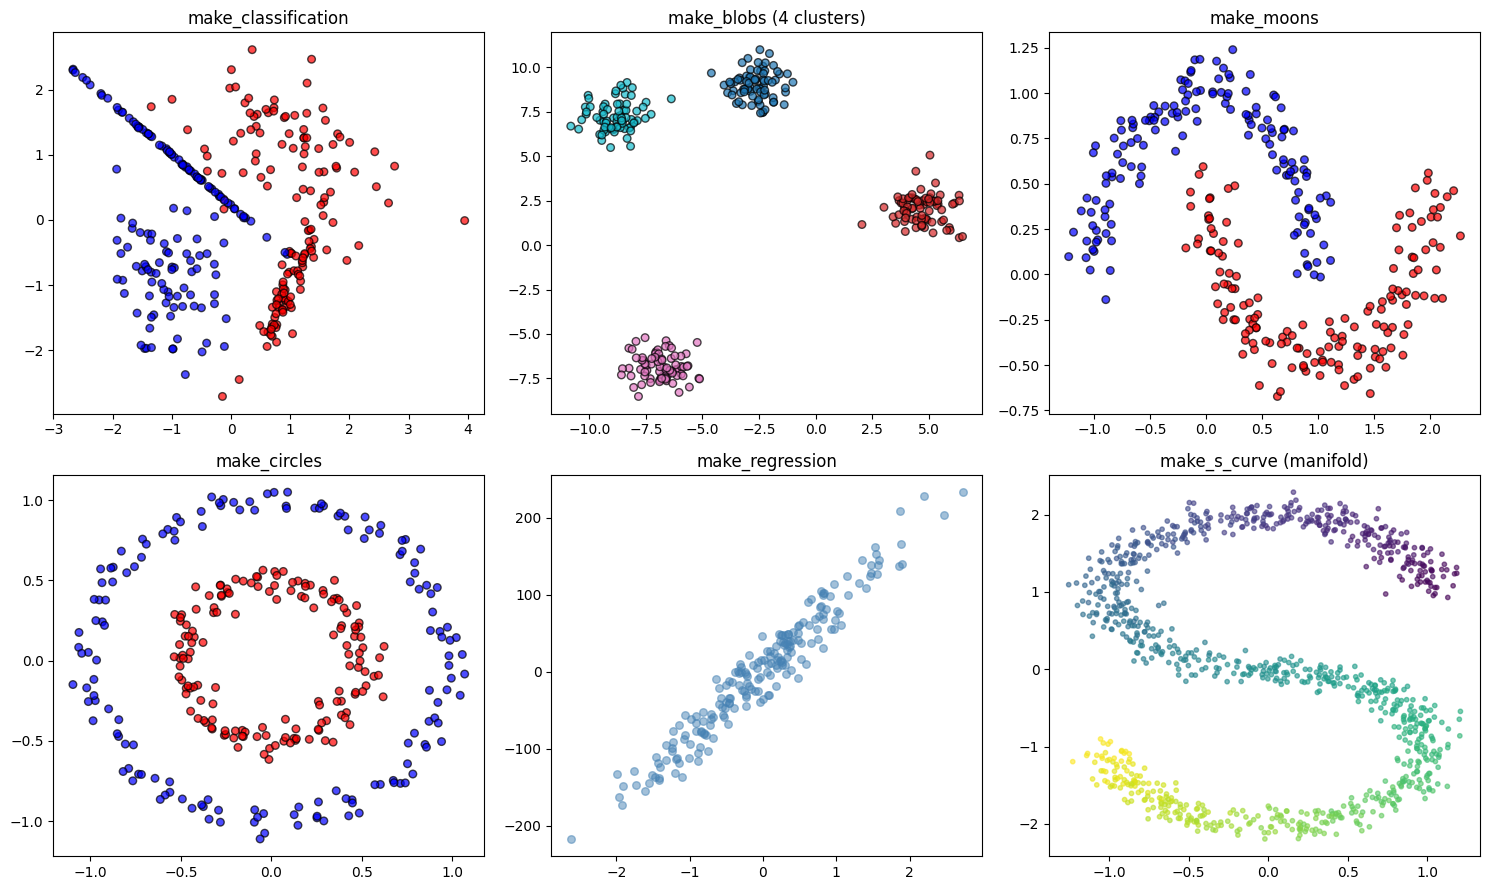

Dataset visualisation complete.


In [516]:
from sklearn.datasets import (make_classification, make_regression,
                              make_blobs, make_moons, make_circles,
                              make_s_curve)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# 1. make_classification
X_c, y_c = make_classification(n_samples=300, n_features=2, n_redundant=0,
                                n_informative=2, random_state=42)
axes[0,0].scatter(X_c[:,0], X_c[:,1], c=y_c, cmap='bwr', alpha=0.7, edgecolors='k', s=30)
axes[0,0].set_title('make_classification', fontsize=12)

# 2. make_blobs
X_b, y_b = make_blobs(n_samples=300, centers=4, cluster_std=0.8, random_state=42)
axes[0,1].scatter(X_b[:,0], X_b[:,1], c=y_b, cmap='tab10', alpha=0.7, edgecolors='k', s=30)
axes[0,1].set_title('make_blobs (4 clusters)', fontsize=12)

# 3. make_moons
X_m, y_m = make_moons(n_samples=300, noise=0.1, random_state=42)
axes[0,2].scatter(X_m[:,0], X_m[:,1], c=y_m, cmap='bwr', alpha=0.7, edgecolors='k', s=30)
axes[0,2].set_title('make_moons', fontsize=12)

# 4. make_circles
X_ci, y_ci = make_circles(n_samples=300, noise=0.05, factor=0.5, random_state=42)
axes[1,0].scatter(X_ci[:,0], X_ci[:,1], c=y_ci, cmap='bwr', alpha=0.7, edgecolors='k', s=30)
axes[1,0].set_title('make_circles', fontsize=12)

# 5. make_regression
X_r, y_r = make_regression(n_samples=200, n_features=1, noise=20, random_state=42)
axes[1,1].scatter(X_r, y_r, alpha=0.5, color='steelblue', s=30)
axes[1,1].set_title('make_regression', fontsize=12)

# 6. make_s_curve
X_s, t_s = make_s_curve(n_samples=1000, noise=0.1, random_state=42)
axes[1,2].scatter(X_s[:,0], X_s[:,2], c=t_s, cmap='viridis', alpha=0.6, s=10)
axes[1,2].set_title('make_s_curve (manifold)', fontsize=12)

plt.tight_layout()
plt.savefig('datasets.png', dpi=100, bbox_inches='tight')
plt.show()
print("Dataset visualisation complete.")


## Module 3 — The Estimator API in Depth

### 3.1 Fitted Parameters and Attributes

By sklearn convention:
- Parameters set in `__init__` are **hyperparameters** — access via `.get_params()`
- Attributes learned during `.fit()` end with **underscore** → `coef_`, `mean_`, `n_iter_`

This makes it easy to distinguish what you configured from what the model learned.


In [517]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0, fit_intercept=True)

# Before fitting — hyperparameters
print("Hyperparameters (before fit):")
print(ridge.get_params())

X, y = make_regression(n_samples=100, n_features=4, noise=5, random_state=0)
ridge.fit(X, y)

# After fitting — learned attributes (end with _)
print("\nLearned attributes (after fit):")
print("  coef_     :", ridge.coef_.round(3))
print("  intercept_:", round(ridge.intercept_, 3))
print("  n_iter_   :", ridge.n_iter_)


Hyperparameters (before fit):
{'alpha': 1.0, 'copy_X': True, 'fit_intercept': True, 'max_iter': None, 'positive': False, 'random_state': None, 'solver': 'auto', 'tol': 0.0001}

Learned attributes (after fit):
  coef_     : [66.489 86.56  34.506 20.384]
  intercept_: 0.07
  n_iter_   : None


### 3.2 `clone()` — Creating Unfitted Copies

`clone()` copies the **hyperparameters** but discards learned attributes. Useful in cross-validation loops.


In [518]:
from sklearn.base import clone

fitted_ridge = Ridge(alpha=0.5).fit(X, y)
print("Before clone — coef_:", fitted_ridge.coef_.round(3))

fresh_ridge = clone(fitted_ridge)
print("After clone  — has coef_?", hasattr(fresh_ridge, 'coef_'))
print("Hyperparameters preserved:", fresh_ridge.get_params())


Before clone — coef_: [66.873 87.005 34.593 20.404]
After clone  — has coef_? False
Hyperparameters preserved: {'alpha': 0.5, 'copy_X': True, 'fit_intercept': True, 'max_iter': None, 'positive': False, 'random_state': None, 'solver': 'auto', 'tol': 0.0001}


## Module 4 — Preprocessing

### 4.1 Feature Scaling

Most distance-based and gradient-based algorithms require features to be on similar scales.  
Sklearn provides several scalers, each with different behaviour:

| Scaler | Formula | Sensitive to outliers? | Use when |
|--------|---------|----------------------|----------|
| `StandardScaler` | (x - mean) / std | Yes | Features roughly Gaussian |
| `MinMaxScaler` | (x - min) / (max - min) | Yes | Bounded range needed |
| `RobustScaler` | (x - median) / IQR | No | Data has outliers |
| `MaxAbsScaler` | x / max(|x|) | Yes | Sparse data |
| `Normalizer` | x / ||x|| (per row) | No | Text, per-sample normalization |


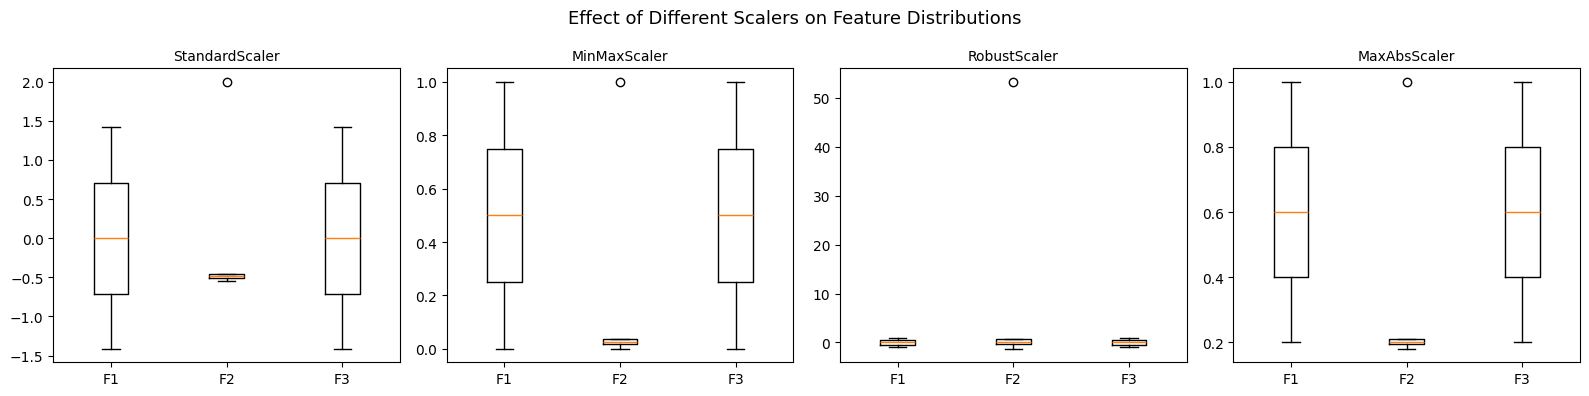

Original F2 values  : [ 200.  180.  195. 1000.  210.]
StandardScaler F2   : [-0.488 -0.55  -0.504  1.999 -0.457]
RobustScaler F2     : [ 0.    -1.333 -0.333 53.333  0.667]


In [519]:
from sklearn.preprocessing import (StandardScaler, MinMaxScaler,
                                   RobustScaler, MaxAbsScaler, Normalizer)
import numpy as np

# Data with an outlier in column 2
X_raw = np.array([[1, 200, 0.1],
                  [2, 180, 0.3],
                  [3, 195, 0.2],
                  [4, 1000, 0.4],   # outlier in column 1 (index 1)
                  [5, 210, 0.5]])

scalers = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler'  : MinMaxScaler(),
    'RobustScaler'  : RobustScaler(),
    'MaxAbsScaler'  : MaxAbsScaler(),
}

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, (name, scaler) in zip(axes, scalers.items()):
    X_scaled = scaler.fit_transform(X_raw)
    ax.boxplot(X_scaled)
    ax.set_title(name, fontsize=10)
    ax.set_xticklabels(['F1', 'F2', 'F3'])

plt.suptitle('Effect of Different Scalers on Feature Distributions', fontsize=13)
plt.tight_layout()
plt.savefig('scalers.png', dpi=100, bbox_inches='tight')
plt.show()

# Print numerical comparison for one feature
print("Original F2 values  :", X_raw[:, 1])
print("StandardScaler F2   :", StandardScaler().fit_transform(X_raw)[:, 1].round(3))
print("RobustScaler F2     :", RobustScaler().fit_transform(X_raw)[:, 1].round(3))


### 4.2 Encoding Categorical Variables

Machines work with numbers, not strings. Sklearn provides:

| Encoder | Output | Use for |
|---------|--------|---------|
| `LabelEncoder` | Integer (0, 1, 2…) | Target variable `y` only |
| `OrdinalEncoder` | Integer per column | Ordinal categories (e.g., Low/Med/High) |
| `OneHotEncoder` | Sparse binary matrix | Nominal categories in `X` |
| `TargetEncoder` | Mean of target per category | High-cardinality categoricals |


In [520]:
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder

# LabelEncoder — for y (target)
le = LabelEncoder()
y_str = ['cat', 'dog', 'cat', 'bird', 'dog', 'bird']
y_enc = le.fit_transform(y_str)
print("LabelEncoder:")
print("  Classes      :", le.classes_)
print("  Encoded      :", y_enc)
print("  Inverse      :", le.inverse_transform(y_enc))

# OrdinalEncoder — for ordered categories in X
oe = OrdinalEncoder(categories=[['Low', 'Medium', 'High']])
X_ord = [['Low'], ['High'], ['Medium'], ['Low'], ['High']]
print("\nOrdinalEncoder:")
print("  Input  :", [x[0] for x in X_ord])
print("  Encoded:", oe.fit_transform(X_ord).flatten())


LabelEncoder:
  Classes      : ['bird' 'cat' 'dog']
  Encoded      : [1 2 1 0 2 0]
  Inverse      : ['cat' 'dog' 'cat' 'bird' 'dog' 'bird']

OrdinalEncoder:
  Input  : ['Low', 'High', 'Medium', 'Low', 'High']
  Encoded: [0. 2. 1. 0. 2.]


In [521]:
# OneHotEncoder — the workhorse for nominal categoricals
X_cat = [['Red', 'Small'],
          ['Blue', 'Large'],
          ['Green', 'Medium'],
          ['Red', 'Large'],
          ['Blue', 'Small']]

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_ohe = ohe.fit_transform(X_cat)

print("OneHotEncoder:")
print("  Feature names:", ohe.get_feature_names_out(['Color', 'Size']))
print("  Encoded matrix:")
print(X_ohe)
print("\n  Shape:", X_ohe.shape, "— original 2 cols expanded to", X_ohe.shape[1])


OneHotEncoder:
  Feature names: ['Color_Blue' 'Color_Green' 'Color_Red' 'Size_Large' 'Size_Medium'
 'Size_Small']
  Encoded matrix:
[[0. 0. 1. 0. 0. 1.]
 [1. 0. 0. 1. 0. 0.]
 [0. 1. 0. 0. 1. 0.]
 [0. 0. 1. 1. 0. 0.]
 [1. 0. 0. 0. 0. 1.]]

  Shape: (5, 6) — original 2 cols expanded to 6


### 4.3 Handling Missing Values with `SimpleImputer`

Real data is dirty. Sklearn's imputers fill missing values using a chosen strategy.


In [522]:
from sklearn.impute import SimpleImputer, KNNImputer
import numpy as np

X_missing = np.array([[1,   2,   np.nan],
                       [4,   np.nan, 6  ],
                       [7,   8,   9   ],
                       [np.nan, 2, 3  ],
                       [5,   6,   np.nan]])

print("Original (NaN = missing):")
print(X_missing)

strategies = ['mean', 'median', 'most_frequent']
for strategy in strategies:
    imp = SimpleImputer(strategy=strategy)
    X_imp = imp.fit_transform(X_missing)
    print(f"\nStrategy='{strategy}':")
    print(X_imp)


Original (NaN = missing):
[[ 1.  2. nan]
 [ 4. nan  6.]
 [ 7.  8.  9.]
 [nan  2.  3.]
 [ 5.  6. nan]]

Strategy='mean':
[[1.   2.   6.  ]
 [4.   4.5  6.  ]
 [7.   8.   9.  ]
 [4.25 2.   3.  ]
 [5.   6.   6.  ]]

Strategy='median':
[[1.  2.  6. ]
 [4.  4.  6. ]
 [7.  8.  9. ]
 [4.5 2.  3. ]
 [5.  6.  6. ]]

Strategy='most_frequent':
[[1. 2. 3.]
 [4. 2. 6.]
 [7. 8. 9.]
 [1. 2. 3.]
 [5. 6. 3.]]


In [523]:
# KNNImputer — uses the K nearest complete neighbours to fill
knn_imp = KNNImputer(n_neighbors=2)
X_knn = knn_imp.fit_transform(X_missing)
print("KNNImputer (n_neighbors=2):")
print(X_knn)


KNNImputer (n_neighbors=2):
[[1.  2.  4.5]
 [4.  4.  6. ]
 [7.  8.  9. ]
 [2.5 2.  3. ]
 [5.  6.  7.5]]


### 4.4 Discretization and Binarization


In [524]:
from sklearn.preprocessing import KBinsDiscretizer, Binarizer, PolynomialFeatures

# Binning continuous features into discrete buckets
X_cont = np.array([[0.5], [1.2], [3.0], [5.8], [7.1], [9.9]])
kbd = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='uniform')
print("Original values  :", X_cont.flatten())
print("Binned (uniform) :", kbd.fit_transform(X_cont).flatten())

kbd_q = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='quantile')
print("Binned (quantile):", kbd_q.fit_transform(X_cont).flatten())

# Binarizer
binarizer = Binarizer(threshold=5.0)
print("\nBinarizer (threshold=5.0):", binarizer.transform(X_cont).flatten())


Original values  : [0.5 1.2 3.  5.8 7.1 9.9]
Binned (uniform) : [0. 0. 0. 1. 2. 2.]
Binned (quantile): [0. 0. 1. 1. 2. 2.]

Binarizer (threshold=5.0): [0. 0. 0. 1. 1. 1.]


## Module 5 — Feature Engineering

### 5.1 Polynomial Features

Polynomial features let linear models capture non-linear relationships  
by creating interaction terms and powers of the original features.

For degree=2 and features [a, b]:  
`[1, a, b, a², ab, b²]`


In [525]:
from sklearn.preprocessing import PolynomialFeatures

X_poly = np.array([[2, 3],
                   [4, 5]])

pf = PolynomialFeatures(degree=2, include_bias=False)
X_transformed = pf.fit_transform(X_poly)

print("Input features          :", ['x1', 'x2'])
print("Output feature names    :", pf.get_feature_names_out(['x1', 'x2']))
print("\nOriginal X:")
print(X_poly)
print("\nPolynomial X (degree=2, no bias):")
print(X_transformed)


Input features          : ['x1', 'x2']
Output feature names    : ['x1' 'x2' 'x1^2' 'x1 x2' 'x2^2']

Original X:
[[2 3]
 [4 5]]

Polynomial X (degree=2, no bias):
[[ 2.  3.  4.  6.  9.]
 [ 4.  5. 16. 20. 25.]]


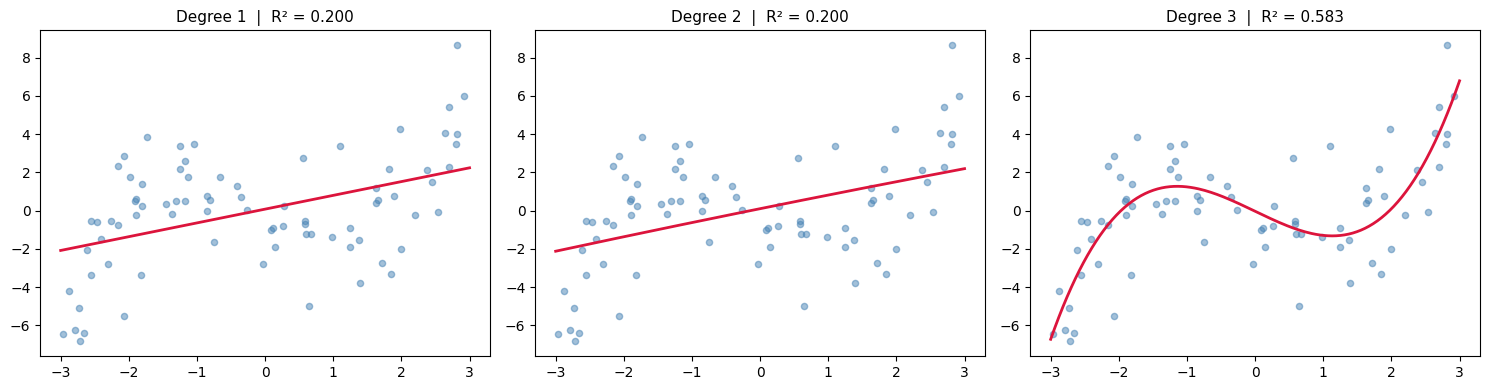

In [526]:
# Polynomial features can dramatically improve linear model fit
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

np.random.seed(42)
X_1d = np.sort(np.random.uniform(-3, 3, 80)).reshape(-1, 1)
y_1d = 0.5 * X_1d.ravel()**3 - 2 * X_1d.ravel() + np.random.randn(80) * 2

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
X_plot = np.linspace(-3, 3, 200).reshape(-1, 1)

for ax, degree in zip(axes, [1, 2, 3]):
    pf = PolynomialFeatures(degree=degree, include_bias=True)
    X_feat = pf.fit_transform(X_1d)
    X_plot_feat = pf.transform(X_plot)
    
    lr = LinearRegression().fit(X_feat, y_1d)
    y_plot = lr.predict(X_plot_feat)
    r2 = r2_score(y_1d, lr.predict(X_feat))
    
    ax.scatter(X_1d, y_1d, alpha=0.5, s=20, color='steelblue')
    ax.plot(X_plot, y_plot, color='crimson', lw=2)
    ax.set_title(f'Degree {degree}  |  R² = {r2:.3f}', fontsize=11)

plt.tight_layout()
plt.savefig('polynomial.png', dpi=100, bbox_inches='tight')
plt.show()


### 5.2 Custom Transformers with `FunctionTransformer`


In [527]:
from sklearn.preprocessing import FunctionTransformer

# Log transformation for right-skewed features
log_transformer = FunctionTransformer(np.log1p, validate=True)

X_skewed = np.array([[1], [10], [100], [1000], [10000]], dtype=float)
X_log = log_transformer.fit_transform(X_skewed)

print("Original  :", X_skewed.flatten())
print("Log1p     :", X_log.flatten().round(3))

# Any arbitrary function can be wrapped
sqrt_transformer = FunctionTransformer(np.sqrt, validate=True)
print("Sqrt      :", sqrt_transformer.fit_transform(np.abs(X_skewed)).flatten().round(3))


Original  : [1.e+00 1.e+01 1.e+02 1.e+03 1.e+04]
Log1p     : [0.693 2.398 4.615 6.909 9.21 ]
Sqrt      : [  1.      3.162  10.     31.623 100.   ]


## Module 6 — Pipelines

### 6.1 `Pipeline` — Chaining Steps

A Pipeline chains transformers and a final estimator into a single object.  
It ensures:
- No data leakage (fitting happens only on training data)
- Clean code — one `fit()` and `predict()` covers the whole workflow
- Easy serialization and deployment


In [528]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                     random_state=42, stratify=y)

# Build the pipeline
pipe = Pipeline([
    ('scaler',  StandardScaler()),
    ('model',   LogisticRegression(max_iter=1000))
])

print("Pipeline steps:")
for name, step in pipe.steps:
    print(f"  {name}: {step}")

# fit only touches training data
pipe.fit(X_train, y_train)
score = pipe.score(X_test, y_test)
print(f"\nTest accuracy: {score:.4f}")


Pipeline steps:
  scaler: StandardScaler()
  model: LogisticRegression(max_iter=1000)

Test accuracy: 0.9825


In [529]:
# Access steps inside a fitted pipeline
print("Scaler mean_ (first 5 features):", pipe['scaler'].mean_[:5].round(3))
print("Model n_iter_                   :", pipe['model'].n_iter_)
print("Model classes_                  :", pipe['model'].classes_)


Scaler mean_ (first 5 features): [1.40670e+01 1.92470e+01 9.15570e+01 6.48541e+02 9.60000e-02]
Model n_iter_                   : [19]
Model classes_                  : [0 1]


### 6.2 `ColumnTransformer` — Different Preprocessing per Column

Real datasets have mixed types: numeric and categorical columns need different pipelines.  
`ColumnTransformer` applies different transformers to different column subsets.


In [530]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

# Create a mixed-type dataset
np.random.seed(42)
n = 200
df_mixed = pd.DataFrame({
    'age'       : np.random.randint(20, 65, n).astype(float),
    'income'    : np.random.normal(50000, 15000, n),
    'education' : np.random.choice(['High School', 'Bachelor', 'Master', 'PhD'], n),
    'city'      : np.random.choice(['Lagos', 'Abuja', 'Kano', 'Ibadan'], n),
    'target'    : np.random.randint(0, 2, n)
})

# Introduce some missing values
df_mixed.loc[np.random.choice(n, 20, replace=False), 'age'] = np.nan
df_mixed.loc[np.random.choice(n, 15, replace=False), 'income'] = np.nan

X_mixed = df_mixed.drop('target', axis=1)
y_mixed = df_mixed['target']

numeric_features    = ['age', 'income']
categorical_features = ['education', 'city']

# Numeric pipeline: impute then scale
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

# Categorical pipeline: impute then one-hot encode
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe',     OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine with ColumnTransformer
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline,    numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

# Full pipeline
full_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',   LogisticRegression(random_state=42))
])

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_mixed, y_mixed, test_size=0.2, random_state=42)

full_pipe.fit(X_train_m, y_train_m)
print("Mixed-type pipeline accuracy:", round(full_pipe.score(X_test_m, y_test_m), 4))

# See the feature names after transformation
feature_names = full_pipe['preprocessor'].get_feature_names_out()
print("\nTransformed feature names:", feature_names)


Mixed-type pipeline accuracy: 0.425

Transformed feature names: ['num__age' 'num__income' 'cat__education_Bachelor'
 'cat__education_High School' 'cat__education_Master' 'cat__education_PhD'
 'cat__city_Abuja' 'cat__city_Ibadan' 'cat__city_Kano' 'cat__city_Lagos']


## Module 7 — Model Selection and Cross-Validation

### 7.1 Train / Validation / Test Splits

The golden rule: **the test set is touched exactly once** — at final evaluation.  
Never use test set performance to make modelling decisions.

```
 Full Dataset
 ├── Training set  (60-70%)   ← model learns from this
 ├── Validation set (15-20%)  ← used to tune hyperparameters
 └── Test set      (15-20%)   ← final unbiased evaluation
```


In [531]:
from sklearn.model_selection import train_test_split

X, y = load_breast_cancer(return_X_y=True)

# Two-step split: train / val / test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.18, random_state=42, stratify=y_trainval)

print(f"Full dataset   : {X.shape[0]} samples")
print(f"Training set   : {X_train.shape[0]} samples  ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation set : {X_val.shape[0]} samples  ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test set       : {X_test.shape[0]} samples  ({X_test.shape[0]/len(X)*100:.1f}%)")

# Check class balance is preserved with stratify=y
print(f"\nClass 0 rate — train: {1-y_train.mean():.3f}  val: {1-y_val.mean():.3f}  test: {1-y_test.mean():.3f}")


Full dataset   : 569 samples
Training set   : 396 samples  (69.6%)
Validation set : 87 samples  (15.3%)
Test set       : 86 samples  (15.1%)

Class 0 rate — train: 0.374  val: 0.368  test: 0.372


### 7.2 Cross-Validation

Cross-validation gives a more reliable estimate of generalisation performance  
by using all data for both training and validation across multiple folds.

**K-Fold CV workflow:**
```
Fold 1:  [VAL | TRN | TRN | TRN | TRN]  → score₁
Fold 2:  [TRN | VAL | TRN | TRN | TRN]  → score₂
Fold 3:  [TRN | TRN | VAL | TRN | TRN]  → score₃
Fold 4:  [TRN | TRN | TRN | VAL | TRN]  → score₄
Fold 5:  [TRN | TRN | TRN | TRN | VAL]  → score₅

Final estimate = mean ± std of [score₁ … score₅]
```


In [532]:
from sklearn.model_selection import (cross_val_score, KFold,
                                     StratifiedKFold, cross_validate,
                                     LeaveOneOut, ShuffleSplit)
from sklearn.svm import SVC

X, y = load_breast_cancer(return_X_y=True)

pipe_cv = Pipeline([
    ('scaler', StandardScaler()),
    ('svc',    SVC(kernel='rbf', C=1.0))
])

# 5-fold cross-validation
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(pipe_cv, X, y, cv=kf, scoring='accuracy')

print("5-Fold CV Accuracy scores:", scores.round(4))
print(f"Mean: {scores.mean():.4f}  ±  Std: {scores.std():.4f}")


5-Fold CV Accuracy scores: [0.9912 0.9474 0.9737 0.9912 0.9823]
Mean: 0.9772  ±  Std: 0.0163


In [533]:
# cross_validate — returns multiple metrics and timing
cv_results = cross_validate(
    pipe_cv, X, y, cv=kf,
    scoring=['accuracy', 'f1', 'roc_auc'],
    return_train_score=True
)

results_df = pd.DataFrame(cv_results)
print("cross_validate results:")
print(results_df.round(4))
print("\nMeans:")
print(results_df.mean().round(4))


cross_validate results:
   fit_time  score_time  test_accuracy  train_accuracy  test_f1  train_f1  \
0    0.0102      0.0122         0.9912          0.9846   0.9929    0.9879   
1    0.0051      0.0095         0.9474          0.9890   0.9583    0.9913   
2    0.0046      0.0088         0.9737          0.9890   0.9796    0.9913   
3    0.0049      0.0087         0.9912          0.9846   0.9930    0.9879   
4    0.0050      0.0091         0.9823          0.9846   0.9861    0.9879   

   test_roc_auc  train_roc_auc  
0        0.9997         0.9978  
1        0.9898         0.9977  
2        0.9851         0.9996  
3        1.0000         0.9975  
4        0.9980         0.9975  

Means:
fit_time          0.0060
score_time        0.0097
test_accuracy     0.9772
train_accuracy    0.9864
test_f1           0.9820
train_f1          0.9893
test_roc_auc      0.9945
train_roc_auc     0.9980
dtype: float64


In [534]:
# Different CV strategies
print("CV Strategy Comparison on Breast Cancer Dataset")
print("="*55)

cv_strategies = {
    'StratifiedKFold(5)': StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    'KFold(10)          ': KFold(n_splits=10, shuffle=True, random_state=42),
    'ShuffleSplit(10)   ': ShuffleSplit(n_splits=10, test_size=0.2, random_state=42),
}

for name, cv in cv_strategies.items():
    s = cross_val_score(pipe_cv, X, y, cv=cv, scoring='accuracy')
    print(f"{name}  mean={s.mean():.4f}  std={s.std():.4f}")


CV Strategy Comparison on Breast Cancer Dataset
StratifiedKFold(5)  mean=0.9772  std=0.0163
KFold(10)            mean=0.9736  std=0.0142
ShuffleSplit(10)     mean=0.9754  std=0.0110


## Module 8 — Supervised Learning: Regression

### 8.1 Linear Regression Family

Linear models fit a hyperplane: `ŷ = Xw + b`  
The regularised variants penalise large weights to reduce overfitting.

| Model | Penalty | Effect |
|-------|---------|--------|
| `LinearRegression` | None | OLS — can overfit |
| `Ridge` | L2: λ·||w||² | Shrinks all weights |
| `Lasso` | L1: λ·||w||₁ | Shrinks + zeros out weights (feature selection) |
| `ElasticNet` | α·L1 + (1-α)·L2 | Combines both |


In [535]:
from sklearn.linear_model import (LinearRegression, Ridge, Lasso,
                                  ElasticNet, BayesianRidge)
from sklearn.metrics import mean_squared_error, r2_score
# Synthetic housing-like dataset (avoids network download)
import types
from sklearn.datasets import make_regression
np.random.seed(42)
_X_h_raw, _y_h_raw = make_regression(n_samples=2000, n_features=8, noise=30, random_state=42)
_y_h_raw = (_y_h_raw - _y_h_raw.min()) / (_y_h_raw.max() - _y_h_raw.min()) * 5 + 0.5
housing = types.SimpleNamespace(
    data=_X_h_raw, target=_y_h_raw,
    feature_names=[f'feature_{i}' for i in range(8)]
)
X_h, y_h = housing.data, housing.target
X_h_train, X_h_test, y_h_train, y_h_test = train_test_split(
    X_h, y_h, test_size=0.2, random_state=42)

scaler_h = StandardScaler()
X_h_train_s = scaler_h.fit_transform(X_h_train)
X_h_test_s  = scaler_h.transform(X_h_test)

models_reg = {
    'LinearRegression': LinearRegression(),
    'Ridge(α=1)'       : Ridge(alpha=1.0),
    'Ridge(α=10)'      : Ridge(alpha=10.0),
    'Lasso(α=0.01)'    : Lasso(alpha=0.01, max_iter=5000),
    'Lasso(α=0.1)'     : Lasso(alpha=0.1,  max_iter=5000),
    'ElasticNet'       : ElasticNet(alpha=0.05, l1_ratio=0.5, max_iter=5000),
    'BayesianRidge'    : BayesianRidge(),
}

print(f"{'Model':<22}  {'Train R²':>9}  {'Test R²':>8}  {'Test RMSE':>10}")
print("-"*55)
for name, model in models_reg.items():
    model.fit(X_h_train_s, y_h_train)
    y_tr = model.predict(X_h_train_s)
    y_te = model.predict(X_h_test_s)
    r2_tr = r2_score(y_h_train, y_tr)
    r2_te = r2_score(y_h_test, y_te)
    rmse  = np.sqrt(mean_squared_error(y_h_test, y_te))
    print(f"{name:<22}  {r2_tr:>9.4f}  {r2_te:>8.4f}  {rmse:>10.4f}")


Model                    Train R²   Test R²   Test RMSE
-------------------------------------------------------
LinearRegression           0.9658    0.9682      0.1290
Ridge(α=1)                 0.9658    0.9682      0.1290
Ridge(α=10)                0.9658    0.9680      0.1295
Lasso(α=0.01)              0.9640    0.9655      0.1344
Lasso(α=0.1)               0.8223    0.8181      0.3087
ElasticNet                 0.9496    0.9494      0.1628
BayesianRidge              0.9658    0.9682      0.1290


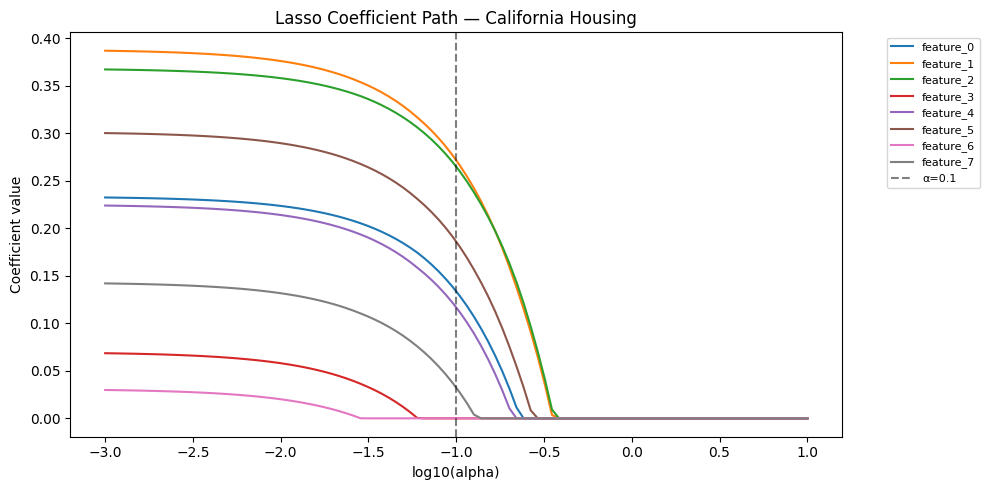

In [536]:
# Lasso coefficient path — the regularisation effect
from sklearn.linear_model import lasso_path

alphas, coef_path, _ = lasso_path(X_h_train_s, y_h_train, alphas=np.logspace(-3, 1, 100))

plt.figure(figsize=(10, 5))
for i, name in enumerate(housing.feature_names):
    plt.plot(np.log10(alphas), coef_path[i].T, label=name)
plt.axvline(x=np.log10(0.1), color='black', linestyle='--', alpha=0.5, label='α=0.1')
plt.xlabel('log10(alpha)')
plt.ylabel('Coefficient value')
plt.title('Lasso Coefficient Path — California Housing')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('lasso_path.png', dpi=100, bbox_inches='tight')
plt.show()


### 8.2 Ensemble Regression Models


In [537]:
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                             ExtraTreesRegressor, AdaBoostRegressor)
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR

ensemble_regressors = {
    'DecisionTree(max_d=5)' : DecisionTreeRegressor(max_depth=5, random_state=42),
    'RandomForest(100)'     : RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'ExtraTrees(100)'       : ExtraTreesRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'GradientBoosting'      : GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
    'AdaBoost'              : AdaBoostRegressor(n_estimators=50, random_state=42),
    'SVR(rbf)'              : SVR(kernel='rbf', C=10),
}

print(f"{'Model':<26}  {'Train R²':>9}  {'Test R²':>8}  {'Test RMSE':>10}")
print("-"*60)
for name, model in ensemble_regressors.items():
    model.fit(X_h_train_s, y_h_train)
    r2_tr = r2_score(y_h_train, model.predict(X_h_train_s))
    y_pred = model.predict(X_h_test_s)
    r2_te  = r2_score(y_h_test, y_pred)
    rmse   = np.sqrt(mean_squared_error(y_h_test, y_pred))
    print(f"{name:<26}  {r2_tr:>9.4f}  {r2_te:>8.4f}  {rmse:>10.4f}")


Model                        Train R²   Test R²   Test RMSE
------------------------------------------------------------
DecisionTree(max_d=5)          0.6805    0.5753      0.4717
RandomForest(100)              0.9787    0.8674      0.2636
ExtraTrees(100)                1.0000    0.8840      0.2466
GradientBoosting               0.9637    0.9159      0.2100
AdaBoost                       0.8059    0.7809      0.3388
SVR(rbf)                       0.9812    0.9400      0.1774


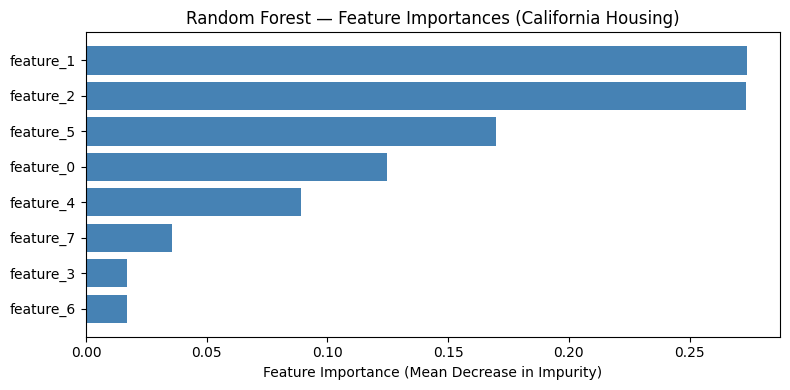

In [538]:
# Feature importance from RandomForest
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_h_train_s, y_h_train)

importance_df = pd.DataFrame({
    'feature'   : housing.feature_names,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(8, 4))
plt.barh(importance_df['feature'], importance_df['importance'], color='steelblue')
plt.xlabel('Feature Importance (Mean Decrease in Impurity)')
plt.title('Random Forest — Feature Importances (California Housing)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()


## Module 9 — Supervised Learning: Classification

### 9.1 Logistic Regression

Despite the name, Logistic Regression is a **linear classifier** — not a regression model.  
It models: `P(y=1|x) = σ(Xw + b)` where σ is the sigmoid function.  
Multi-class strategies: `ovr` (one-vs-rest) or `multinomial` (softmax).


In [539]:
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_iris, load_breast_cancer
from sklearn.metrics import accuracy_score, classification_report

X_iris, y_iris = load_iris(return_X_y=True)
X_bc, y_bc = load_breast_cancer(return_X_y=True)

# Binary classification
X_b_tr, X_b_te, y_b_tr, y_b_te = train_test_split(X_bc, y_bc, test_size=0.2,
                                                    random_state=42, stratify=y_bc)
pipe_lr = Pipeline([('s', StandardScaler()), ('lr', LogisticRegression(max_iter=1000))])
pipe_lr.fit(X_b_tr, y_b_tr)

print("=== Logistic Regression — Breast Cancer (Binary) ===")
print(classification_report(y_b_te, pipe_lr.predict(X_b_te),
                             target_names=load_breast_cancer().target_names))


=== Logistic Regression — Breast Cancer (Binary) ===
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [540]:
# Multi-class with Iris (3 classes)
X_i_tr, X_i_te, y_i_tr, y_i_te = train_test_split(X_iris, y_iris, test_size=0.2,
                                                    random_state=42, stratify=y_iris)

lr_multi = Pipeline([
    ('s',  StandardScaler()),
    ('lr', LogisticRegression(solver='lbfgs', max_iter=500))
])
lr_multi.fit(X_i_tr, y_i_tr)

print("=== Logistic Regression — Iris (Multi-class) ===")
print(classification_report(y_i_te, lr_multi.predict(X_i_te),
                             target_names=load_iris().target_names))

# Predicted probabilities
proba = lr_multi.predict_proba(X_i_te[:5])
print("\nPredicted probabilities for first 5 test samples:")
prob_df = pd.DataFrame(proba, columns=load_iris().target_names)
print(prob_df.round(4))


=== Logistic Regression — Iris (Multi-class) ===
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30


Predicted probabilities for first 5 test samples:
   setosa  versicolor  virginica
0  0.9788      0.0212     0.0000
1  0.0038      0.3692     0.6270
2  0.1488      0.8425     0.0087
3  0.0954      0.8946     0.0099
4  0.9885      0.0115     0.0000


### 9.2 Support Vector Machines (SVM)

SVMs find the **maximum-margin hyperplane** separating classes.  
The kernel trick maps data to higher dimensions where it becomes linearly separable.

| Kernel | Use when |
|--------|----------|
| `linear` | Linearly separable, many features, text data |
| `rbf` | General-purpose, most classification tasks |
| `poly` | Polynomial relationships |
| `sigmoid` | Neural network-like behaviour |


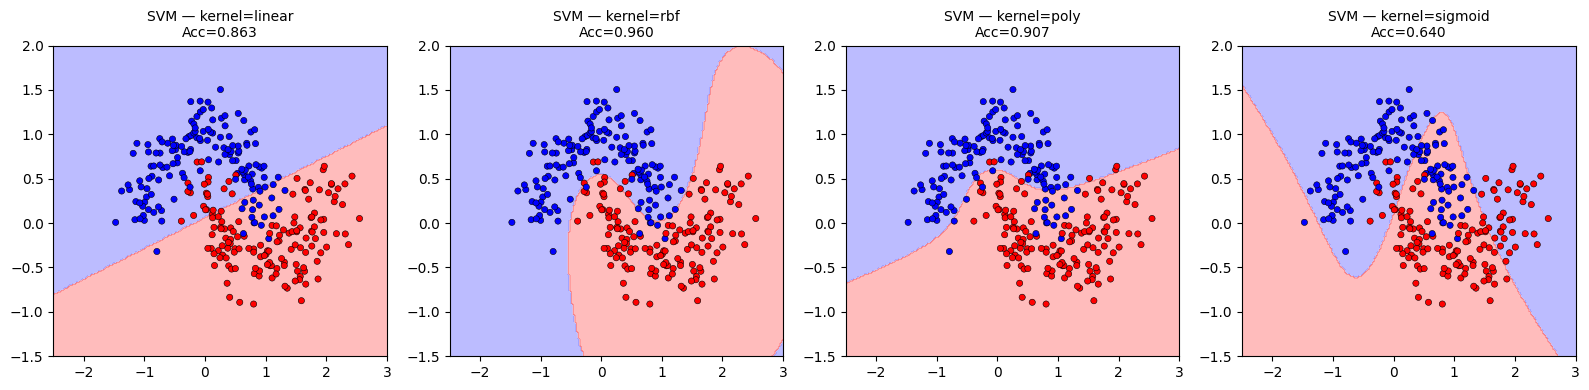

In [541]:
from sklearn.svm import SVC

# Visualise decision boundaries for different kernels
X_2d, y_2d = make_moons(n_samples=300, noise=0.2, random_state=42)

kernels = ['linear', 'rbf', 'poly', 'sigmoid']
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

xx, yy = np.meshgrid(np.linspace(-2.5, 3, 200), np.linspace(-1.5, 2, 200))
X_grid = np.c_[xx.ravel(), yy.ravel()]

for ax, kernel in zip(axes, kernels):
    svm = SVC(kernel=kernel, C=1.0, gamma='scale')
    svm.fit(X_2d, y_2d)
    Z = svm.predict(X_grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='bwr')
    ax.scatter(X_2d[:,0], X_2d[:,1], c=y_2d, cmap='bwr',
               edgecolors='k', s=20, linewidths=0.4)
    ax.set_title(f'SVM — kernel={kernel}\nAcc={svm.score(X_2d,y_2d):.3f}', fontsize=10)

plt.tight_layout()
plt.savefig('svm_kernels.png', dpi=100, bbox_inches='tight')
plt.show()


### 9.3 Decision Trees


In [542]:
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree

X_tree, y_tree = load_iris(return_X_y=True)
X_tr, X_te, y_tr, y_te = train_test_split(X_tree, y_tree, test_size=0.2, random_state=42)

dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_tr, y_tr)

print(f"Train accuracy: {dt.score(X_tr, y_tr):.4f}")
print(f"Test accuracy : {dt.score(X_te, y_te):.4f}")
print(f"Tree depth    : {dt.get_depth()}")
print(f"Leaf nodes    : {dt.get_n_leaves()}")

print("\nText representation:")
print(export_text(dt, feature_names=load_iris().feature_names))


Train accuracy: 0.9583
Test accuracy : 1.0000
Tree depth    : 3
Leaf nodes    : 5

Text representation:
|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal length (cm) <= 4.75
|   |   |--- petal width (cm) <= 1.65
|   |   |   |--- class: 1
|   |   |--- petal width (cm) >  1.65
|   |   |   |--- class: 2
|   |--- petal length (cm) >  4.75
|   |   |--- petal width (cm) <= 1.75
|   |   |   |--- class: 1
|   |   |--- petal width (cm) >  1.75
|   |   |   |--- class: 2



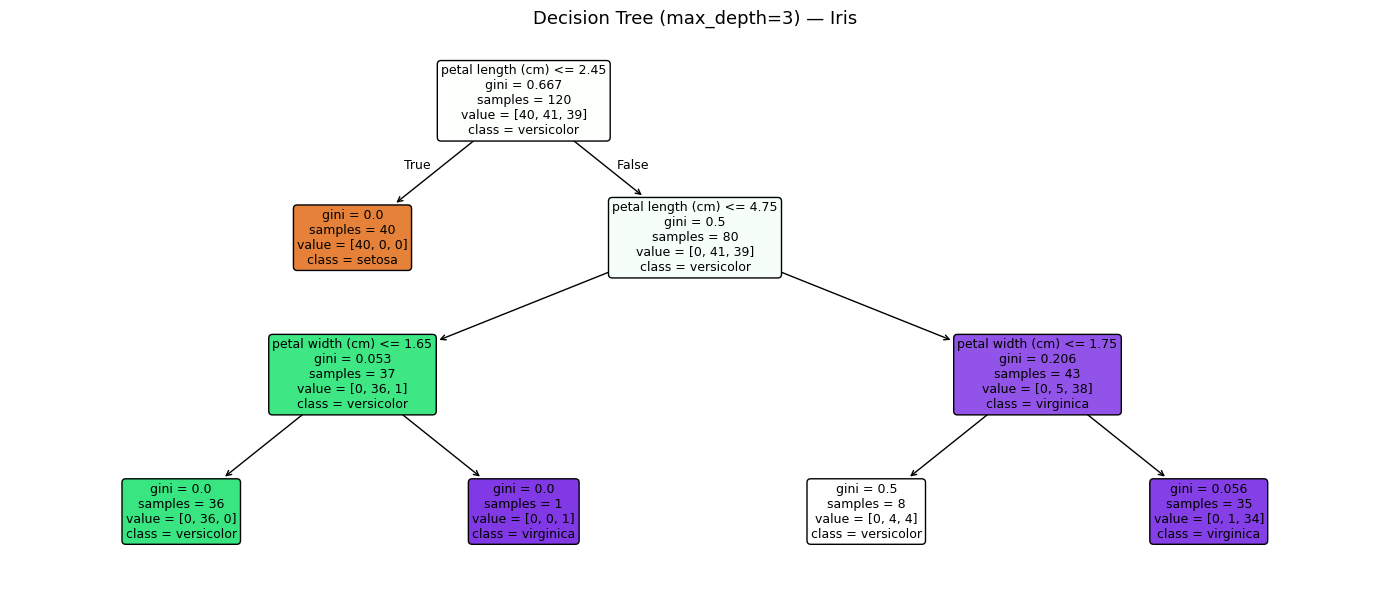

In [543]:
# Visualise the tree
fig, ax = plt.subplots(figsize=(14, 6))
plot_tree(dt, feature_names=load_iris().feature_names,
          class_names=load_iris().target_names,
          filled=True, rounded=True, ax=ax, fontsize=9)
plt.title('Decision Tree (max_depth=3) — Iris', fontsize=13)
plt.tight_layout()
plt.savefig('decision_tree.png', dpi=100, bbox_inches='tight')
plt.show()


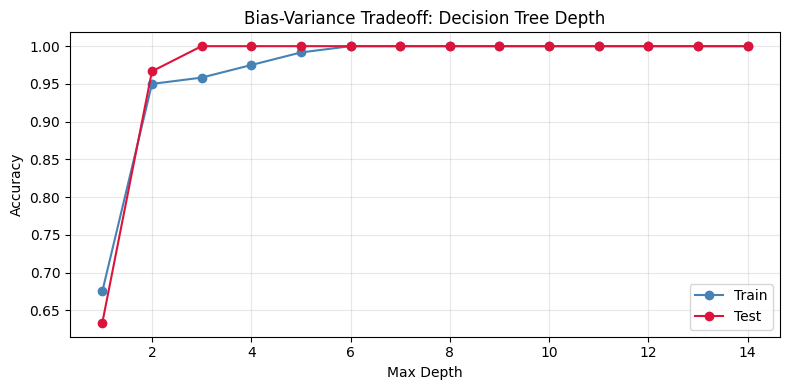

In [544]:
# Effect of tree depth on bias-variance tradeoff
train_scores, test_scores = [], []
depths = range(1, 15)

for d in depths:
    dt_d = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt_d.fit(X_tr, y_tr)
    train_scores.append(dt_d.score(X_tr, y_tr))
    test_scores.append(dt_d.score(X_te, y_te))

plt.figure(figsize=(8, 4))
plt.plot(depths, train_scores, 'o-', label='Train', color='steelblue')
plt.plot(depths, test_scores,  'o-', label='Test',  color='crimson')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Bias-Variance Tradeoff: Decision Tree Depth')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('depth_tradeoff.png', dpi=100, bbox_inches='tight')
plt.show()


### 9.4 Ensemble Classifiers


In [545]:
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                             AdaBoostClassifier, ExtraTreesClassifier,
                             BaggingClassifier, VotingClassifier)
from sklearn.neighbors import KNeighborsClassifier

X_bc, y_bc = load_breast_cancer(return_X_y=True)
X_b_tr, X_b_te, y_b_tr, y_b_te = train_test_split(X_bc, y_bc, test_size=0.2,
                                                    random_state=42, stratify=y_bc)
scaler_bc = StandardScaler()
X_b_tr_s = scaler_bc.fit_transform(X_b_tr)
X_b_te_s  = scaler_bc.transform(X_b_te)

classifiers = {
    'LogisticRegression'    : LogisticRegression(max_iter=1000),
    'KNN(k=7)'              : KNeighborsClassifier(n_neighbors=7),
    'SVC(rbf)'              : SVC(probability=True),
    'DecisionTree'          : DecisionTreeClassifier(max_depth=5, random_state=42),
    'RandomForest(200)'     : RandomForestClassifier(n_estimators=200, random_state=42),
    'ExtraTrees(200)'       : ExtraTreesClassifier(n_estimators=200, random_state=42),
    'GradientBoosting'      : GradientBoostingClassifier(n_estimators=100, random_state=42),
    'AdaBoost'              : AdaBoostClassifier(n_estimators=100, random_state=42),
}

print(f"{'Model':<26}  {'Train Acc':>10}  {'Test Acc':>9}")
print("-"*50)
for name, clf in classifiers.items():
    clf.fit(X_b_tr_s, y_b_tr)
    tr_acc = clf.score(X_b_tr_s, y_b_tr)
    te_acc = clf.score(X_b_te_s,  y_b_te)
    print(f"{name:<26}  {tr_acc:>10.4f}  {te_acc:>9.4f}")


Model                        Train Acc   Test Acc
--------------------------------------------------
LogisticRegression              0.9890     0.9825
KNN(k=7)                        0.9758     0.9737
SVC(rbf)                        0.9824     0.9825
DecisionTree                    0.9934     0.9211
RandomForest(200)               1.0000     0.9561
ExtraTrees(200)                 1.0000     0.9561
GradientBoosting                1.0000     0.9561
AdaBoost                        1.0000     0.9561


### 9.5 Voting Classifier


In [546]:
# VotingClassifier — combines multiple models
from sklearn.ensemble import VotingClassifier

voting_clf = VotingClassifier(estimators=[
    ('lr',  LogisticRegression(max_iter=1000)),
    ('rf',  RandomForestClassifier(n_estimators=100, random_state=42)),
    ('svc', SVC(probability=True)),
], voting='soft')  # 'soft' uses probabilities; 'hard' uses majority vote

voting_clf.fit(X_b_tr_s, y_b_tr)
print("VotingClassifier (soft) accuracy:", round(voting_clf.score(X_b_te_s, y_b_te), 4))

# Individual vs ensemble
for name, clf in voting_clf.named_estimators_.items():
    print(f"  {name} alone: {round(clf.score(X_b_te_s, y_b_te), 4)}")


VotingClassifier (soft) accuracy: 0.9737
  lr alone: 0.9825
  rf alone: 0.9561
  svc alone: 0.9825


## Module 10 — Evaluation Metrics

### 10.1 Regression Metrics

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| MAE | mean(|ŷ - y|) | Average absolute error; same units as y |
| MSE | mean((ŷ - y)²) | Penalises large errors more |
| RMSE | √MSE | Same units as y; more interpretable than MSE |
| R² | 1 - SS_res/SS_tot | Proportion of variance explained (1 = perfect) |
| MAPE | mean(|ŷ-y|/|y|) × 100 | Percentage error |


Regression Metrics (California Housing — RandomForest):
  MAE   = 0.2098  (avg house value error ≈ $20984)
  RMSE  = 0.2636
  R²    = 0.8674  (86.7% of variance explained)
  MAPE  = 8.06%


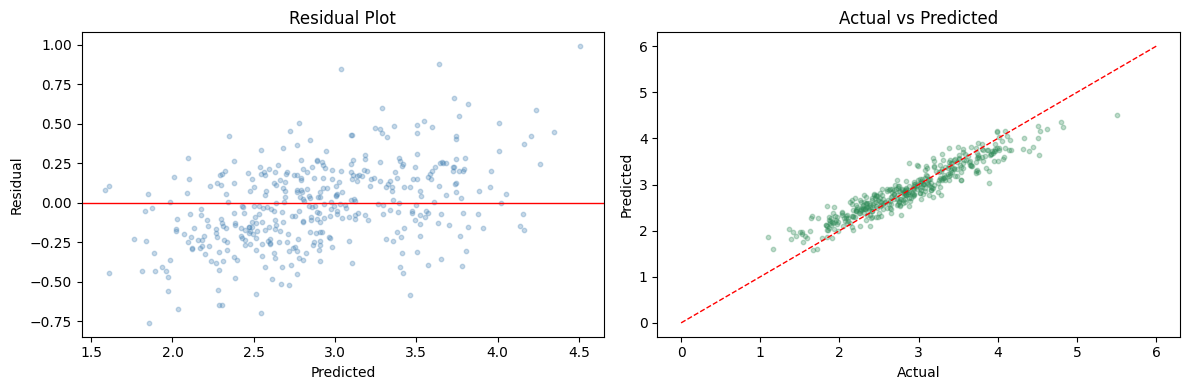

In [547]:
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                              r2_score, mean_absolute_percentage_error)
from sklearn.ensemble import RandomForestRegressor

# Synthetic housing-like dataset (avoids network download)
import types
from sklearn.datasets import make_regression
np.random.seed(42)
_X_h_raw, _y_h_raw = make_regression(n_samples=2000, n_features=8, noise=30, random_state=42)
_y_h_raw = (_y_h_raw - _y_h_raw.min()) / (_y_h_raw.max() - _y_h_raw.min()) * 5 + 0.5
housing = types.SimpleNamespace(
    data=_X_h_raw, target=_y_h_raw,
    feature_names=[f'feature_{i}' for i in range(8)]
)
X_h, y_h = housing.data, housing.target
X_h_tr, X_h_te, y_h_tr, y_h_te = train_test_split(X_h, y_h, test_size=0.2, random_state=42)

rf_h = Pipeline([('s', StandardScaler()),
                  ('m', RandomForestRegressor(n_estimators=100, random_state=42))])
rf_h.fit(X_h_tr, y_h_tr)
y_pred_h = rf_h.predict(X_h_te)

mae  = mean_absolute_error(y_h_te, y_pred_h)
mse  = mean_squared_error(y_h_te, y_pred_h)
rmse = np.sqrt(mse)
r2   = r2_score(y_h_te, y_pred_h)
mape = mean_absolute_percentage_error(y_h_te, y_pred_h) * 100

print("Regression Metrics (California Housing — RandomForest):")
print(f"  MAE   = {mae:.4f}  (avg house value error ≈ ${mae*100000:.0f})")
print(f"  RMSE  = {rmse:.4f}")
print(f"  R²    = {r2:.4f}  ({r2*100:.1f}% of variance explained)")
print(f"  MAPE  = {mape:.2f}%")

# Residual plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
residuals = y_h_te - y_pred_h
axes[0].scatter(y_pred_h, residuals, alpha=0.3, s=10, color='steelblue')
axes[0].axhline(0, color='red', lw=1)
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Residual')
axes[0].set_title('Residual Plot')

axes[1].scatter(y_h_te, y_pred_h, alpha=0.3, s=10, color='seagreen')
lims = [0, 6]
axes[1].plot(lims, lims, 'r--', lw=1)
axes[1].set_xlabel('Actual'); axes[1].set_ylabel('Predicted')
axes[1].set_title('Actual vs Predicted')

plt.tight_layout()
plt.savefig('residuals.png', dpi=100, bbox_inches='tight')
plt.show()


### 10.2 Classification Metrics


In [548]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              ConfusionMatrixDisplay, classification_report,
                              roc_curve, precision_recall_curve, average_precision_score)

X_bc, y_bc = load_breast_cancer(return_X_y=True)
X_b_tr, X_b_te, y_b_tr, y_b_te = train_test_split(X_bc, y_bc, test_size=0.2,
                                                     random_state=42, stratify=y_bc)
pipe_final = Pipeline([('s', StandardScaler()),
                        ('m', RandomForestClassifier(n_estimators=200, random_state=42))])
pipe_final.fit(X_b_tr, y_b_tr)
y_pred_bc = pipe_final.predict(X_b_te)
y_prob_bc  = pipe_final.predict_proba(X_b_te)[:, 1]

print("=== Classification Metrics — Breast Cancer ===")
print(f"Accuracy  : {accuracy_score(y_b_te, y_pred_bc):.4f}")
print(f"Precision : {precision_score(y_b_te, y_pred_bc):.4f}")
print(f"Recall    : {recall_score(y_b_te, y_pred_bc):.4f}")
print(f"F1 Score  : {f1_score(y_b_te, y_pred_bc):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_b_te, y_prob_bc):.4f}")
print("\n", classification_report(y_b_te, y_pred_bc,
                                  target_names=load_breast_cancer().target_names))


=== Classification Metrics — Breast Cancer ===
Accuracy  : 0.9561
Precision : 0.9589
Recall    : 0.9722
F1 Score  : 0.9655
ROC-AUC   : 0.9932

               precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



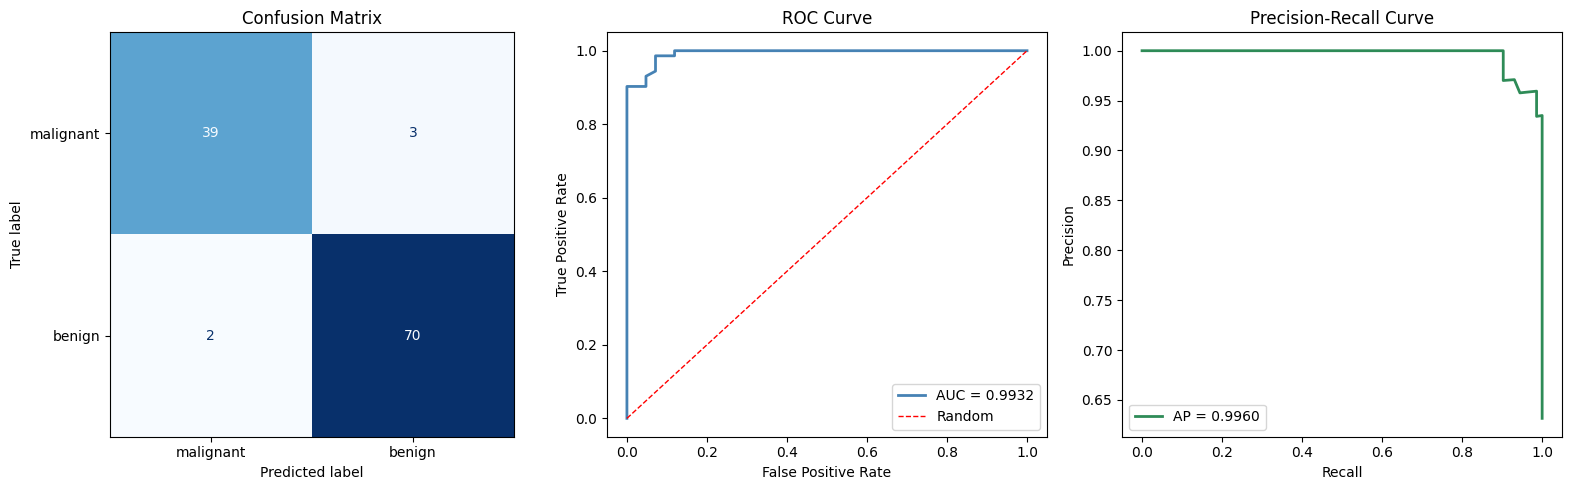

In [549]:
# Confusion Matrix + ROC Curve + Precision-Recall Curve
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Confusion Matrix
cm = confusion_matrix(y_b_te, y_pred_bc)
disp = ConfusionMatrixDisplay(cm, display_labels=load_breast_cancer().target_names)
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix')

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_b_te, y_prob_bc)
auc = roc_auc_score(y_b_te, y_prob_bc)
axes[1].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {auc:.4f}')
axes[1].plot([0,1],[0,1], 'r--', lw=1, label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()

# Precision-Recall Curve
precision_v, recall_v, _ = precision_recall_curve(y_b_te, y_prob_bc)
ap = average_precision_score(y_b_te, y_prob_bc)
axes[2].plot(recall_v, precision_v, color='seagreen', lw=2, label=f'AP = {ap:.4f}')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve')
axes[2].legend()

plt.tight_layout()
plt.savefig('classification_metrics.png', dpi=100, bbox_inches='tight')
plt.show()


### 10.3 Understanding the Confusion Matrix

```
                Predicted Negative | Predicted Positive
Actual Negative |      TN           |       FP           (Type I error)
Actual Positive |      FN           |       TP           
                  (Type II error)

Accuracy   = (TP + TN) / Total
Precision  = TP / (TP + FP)   ← "Of all predicted positives, how many are correct?"
Recall     = TP / (TP + FN)   ← "Of all actual positives, how many did we catch?"
F1         = 2 × (Precision × Recall) / (Precision + Recall)
```

**Which metric to use?**
- **Imbalanced data** → avoid accuracy; use F1, ROC-AUC, or PR-AUC
- **High cost of false negatives** (cancer screening) → maximise Recall
- **High cost of false positives** (spam detection) → maximise Precision
- **Balanced concern** → F1 Score or ROC-AUC


## Module 11 — Hyperparameter Tuning

### 11.1 GridSearchCV

GridSearchCV exhaustively searches all combinations of hyperparameters.  
It uses cross-validation internally to estimate generalisation performance.

**Warning:** Grid search grows exponentially — be mindful with many parameters.


In [550]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.svm import SVC

X, y = load_breast_cancer(return_X_y=True)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

pipe_svc = Pipeline([('scaler', StandardScaler()), ('svc', SVC(probability=True))])

param_grid = {
    'svc__C'      : [0.1, 1, 10, 100],
    'svc__kernel' : ['rbf', 'linear'],
    'svc__gamma'  : ['scale', 'auto', 0.01, 0.001],
}

grid_search = GridSearchCV(pipe_svc, param_grid,
                            cv=StratifiedKFold(5, shuffle=True, random_state=42),
                            scoring='f1',
                            n_jobs=-1,
                            verbose=1,
                            return_train_score=True)
grid_search.fit(X_tr, y_tr)

print("Best parameters :", grid_search.best_params_)
print("Best CV F1      :", round(grid_search.best_score_, 4))
print("Test F1         :", round(f1_score(y_te, grid_search.predict(X_te)), 4))
print("Test ROC-AUC    :", round(roc_auc_score(y_te, grid_search.predict_proba(X_te)[:,1]), 4))


Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best parameters : {'svc__C': 0.1, 'svc__gamma': 'scale', 'svc__kernel': 'linear'}
Best CV F1      : 0.981
Test F1         : 0.9861
Test ROC-AUC    : 0.9937


In [551]:
# Inspect full grid search results
results_df = pd.DataFrame(grid_search.cv_results_)
results_df = results_df[['param_svc__C', 'param_svc__kernel', 'param_svc__gamma',
                          'mean_train_score', 'mean_test_score', 'std_test_score', 'rank_test_score']]
results_df = results_df.sort_values('rank_test_score')
print("Top 10 parameter combinations:")
print(results_df.head(10).to_string(index=False))


Top 10 parameter combinations:
 param_svc__C param_svc__kernel param_svc__gamma  mean_train_score  mean_test_score  std_test_score  rank_test_score
          0.1            linear            scale          0.988678         0.981015        0.008191                1
          0.1            linear             auto          0.988678         0.981015        0.008191                1
          0.1            linear            0.001          0.988678         0.981015        0.008191                1
          0.1            linear             0.01          0.988678         0.981015        0.008191                1
         10.0               rbf             0.01          0.991282         0.980987        0.012472                5
         10.0               rbf            0.001          0.986125         0.977856        0.015344                6
          1.0               rbf             0.01          0.986125         0.977628        0.011553                7
        100.0               rbf  

### 11.2 RandomizedSearchCV

Randomly samples hyperparameter combinations — more efficient than grid search  
when the search space is large. Specify distributions, not fixed lists.


In [552]:
from scipy.stats import loguniform, randint
from sklearn.ensemble import GradientBoostingClassifier

param_dist = {
    'n_estimators'  : randint(50, 300),
    'learning_rate' : loguniform(0.01, 0.5),
    'max_depth'     : randint(2, 8),
    'min_samples_split' : randint(2, 20),
    'subsample'     : [0.6, 0.7, 0.8, 0.9, 1.0],
}

random_search = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=30,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42,
    verbose=0
)
random_search.fit(X_tr, y_tr)

print("Best params    :", random_search.best_params_)
print("Best CV AUC    :", round(random_search.best_score_, 4))
print("Test AUC       :", round(roc_auc_score(y_te, random_search.predict_proba(X_te)[:,1]), 4))


Best params    : {'learning_rate': np.float64(0.14316013583282228), 'max_depth': 2, 'min_samples_split': 8, 'n_estimators': 67, 'subsample': 0.9}
Best CV AUC    : 0.9936
Test AUC       : 0.9931


### 11.3 Learning Curves and Validation Curves


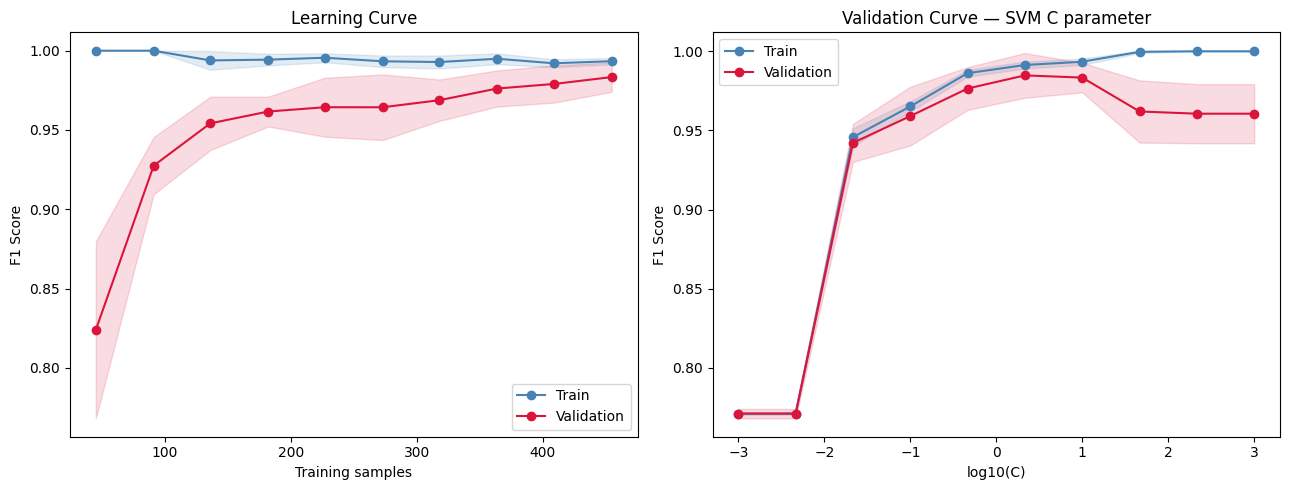

In [553]:
from sklearn.model_selection import learning_curve, validation_curve

# Learning curve — effect of training set size
train_sizes, train_scores, val_scores = learning_curve(
    Pipeline([('s', StandardScaler()), ('m', SVC(C=10, gamma='scale'))]),
    X, y,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='f1',
    n_jobs=-1
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].fill_between(train_sizes,
                      train_scores.mean(1) - train_scores.std(1),
                      train_scores.mean(1) + train_scores.std(1), alpha=0.15, color='steelblue')
axes[0].fill_between(train_sizes,
                      val_scores.mean(1) - val_scores.std(1),
                      val_scores.mean(1) + val_scores.std(1), alpha=0.15, color='crimson')
axes[0].plot(train_sizes, train_scores.mean(1), 'o-', color='steelblue', label='Train')
axes[0].plot(train_sizes, val_scores.mean(1),   'o-', color='crimson',   label='Validation')
axes[0].set_xlabel('Training samples'); axes[0].set_ylabel('F1 Score')
axes[0].set_title('Learning Curve'); axes[0].legend()

# Validation curve — effect of C parameter
C_range = np.logspace(-3, 3, 10)
tr_v, val_v = validation_curve(
    Pipeline([('s', StandardScaler()), ('m', SVC(gamma='scale'))]),
    X, y,
    param_name='m__C',
    param_range=C_range,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring='f1',
    n_jobs=-1
)

axes[1].fill_between(np.log10(C_range),
                      tr_v.mean(1) - tr_v.std(1),
                      tr_v.mean(1) + tr_v.std(1), alpha=0.15, color='steelblue')
axes[1].fill_between(np.log10(C_range),
                      val_v.mean(1) - val_v.std(1),
                      val_v.mean(1) + val_v.std(1), alpha=0.15, color='crimson')
axes[1].plot(np.log10(C_range), tr_v.mean(1),  'o-', color='steelblue', label='Train')
axes[1].plot(np.log10(C_range), val_v.mean(1), 'o-', color='crimson',   label='Validation')
axes[1].set_xlabel('log10(C)'); axes[1].set_ylabel('F1 Score')
axes[1].set_title('Validation Curve — SVM C parameter'); axes[1].legend()

plt.tight_layout()
plt.savefig('curves.png', dpi=100, bbox_inches='tight')
plt.show()


## Module 12 — Unsupervised Learning

### 12.1 K-Means Clustering

K-Means partitions data into **k** clusters by minimising within-cluster variance.  
**Algorithm:**
1. Randomly initialise k centroids
2. Assign each point to the nearest centroid
3. Update centroids to the mean of their assigned points
4. Repeat until convergence


KMeans Results:
  Inertia (within-cluster SS) : 490.57
  Silhouette Score (0-1)       : 0.8350
  Calinski-Harabasz Score      : 7127.52
  Cluster sizes                : [100 100 100 100]


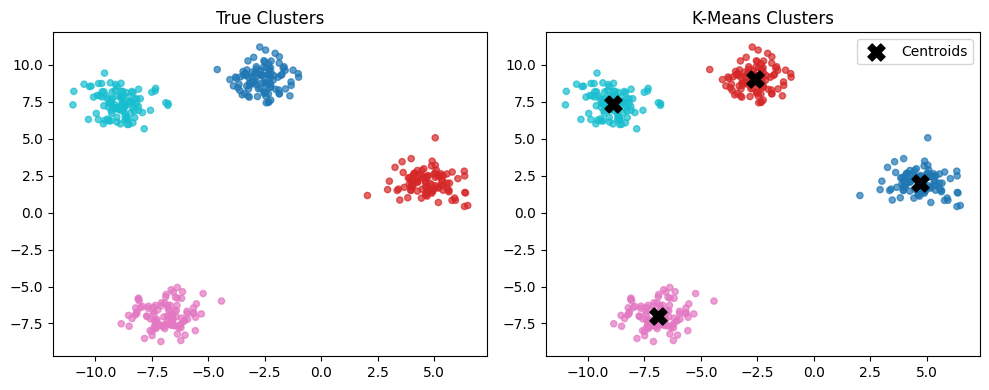

In [554]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score

X_cl, y_true = make_blobs(n_samples=400, centers=4, cluster_std=0.8, random_state=42)

# Fit KMeans
kmeans = KMeans(n_clusters=4, n_init=10, random_state=42)
labels = kmeans.fit_predict(X_cl)

print("KMeans Results:")
print(f"  Inertia (within-cluster SS) : {kmeans.inertia_:.2f}")
print(f"  Silhouette Score (0-1)       : {silhouette_score(X_cl, labels):.4f}")
print(f"  Calinski-Harabasz Score      : {calinski_harabasz_score(X_cl, labels):.2f}")
print(f"  Cluster sizes                : {np.bincount(labels)}")

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.scatter(X_cl[:,0], X_cl[:,1], c=y_true, cmap='tab10', s=20, alpha=0.7)
plt.title('True Clusters')

plt.subplot(1, 2, 2)
plt.scatter(X_cl[:,0], X_cl[:,1], c=labels, cmap='tab10', s=20, alpha=0.7)
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1],
            c='black', marker='X', s=150, zorder=5, label='Centroids')
plt.legend()
plt.title('K-Means Clusters')
plt.tight_layout()
plt.savefig('kmeans.png', dpi=100, bbox_inches='tight')
plt.show()


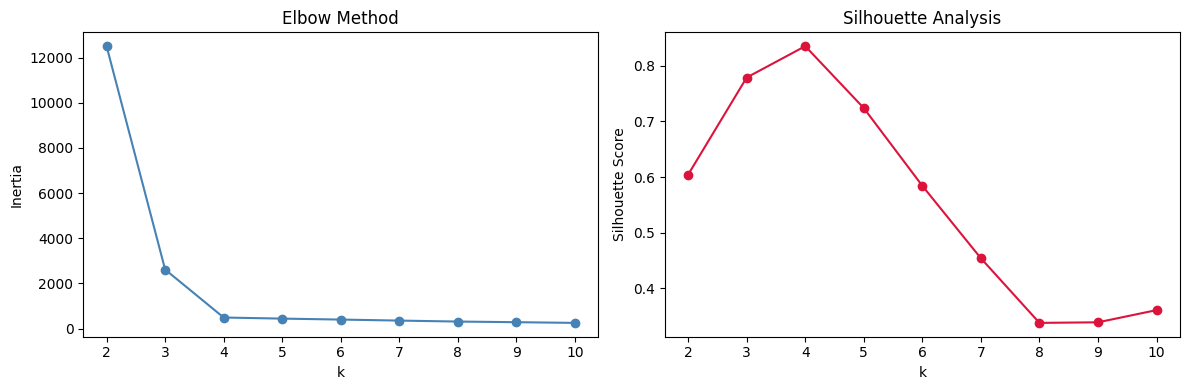

Optimal k by silhouette: k=4


In [555]:
# The Elbow Method + Silhouette to find optimal k
inertias, silhouettes = [], []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    lbl = km.fit_predict(X_cl)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_cl, lbl))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(k_range, inertias, 'o-', color='steelblue')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')

axes[1].plot(k_range, silhouettes, 'o-', color='crimson')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Analysis')

plt.tight_layout()
plt.savefig('elbow.png', dpi=100, bbox_inches='tight')
plt.show()
print(f"Optimal k by silhouette: k={k_range[np.argmax(silhouettes)]}")


### 12.2 DBSCAN — Density-Based Clustering

DBSCAN discovers clusters of arbitrary shape and marks outliers as noise.  
It requires no pre-specified k.

**Parameters:**
- `eps` — neighbourhood radius
- `min_samples` — minimum points to form a core point


DBSCAN found 2 clusters, 3 noise points


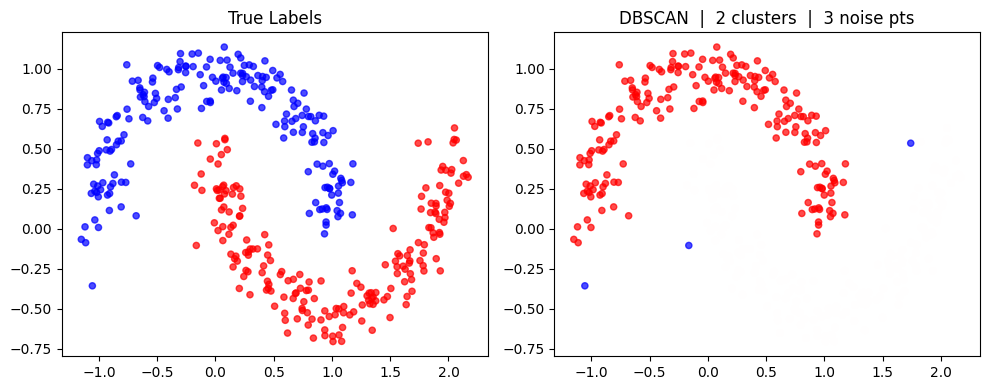

In [556]:
from sklearn.cluster import DBSCAN, AgglomerativeClustering

# DBSCAN shines on non-convex shapes
X_db, y_db = make_moons(n_samples=400, noise=0.1, random_state=42)

dbscan = DBSCAN(eps=0.2, min_samples=5)
db_labels = dbscan.fit_predict(X_db)

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = (db_labels == -1).sum()

print(f"DBSCAN found {n_clusters} clusters, {n_noise} noise points")

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.scatter(X_db[:,0], X_db[:,1], c=y_db, cmap='bwr', s=20, alpha=0.7)
plt.title('True Labels')

plt.subplot(1, 2, 2)
plt.scatter(X_db[:,0], X_db[:,1], c=db_labels, cmap='bwr', s=20, alpha=0.7)
plt.title(f'DBSCAN  |  {n_clusters} clusters  |  {n_noise} noise pts')

plt.tight_layout()
plt.savefig('dbscan.png', dpi=100, bbox_inches='tight')
plt.show()


### 12.3 Agglomerative (Hierarchical) Clustering


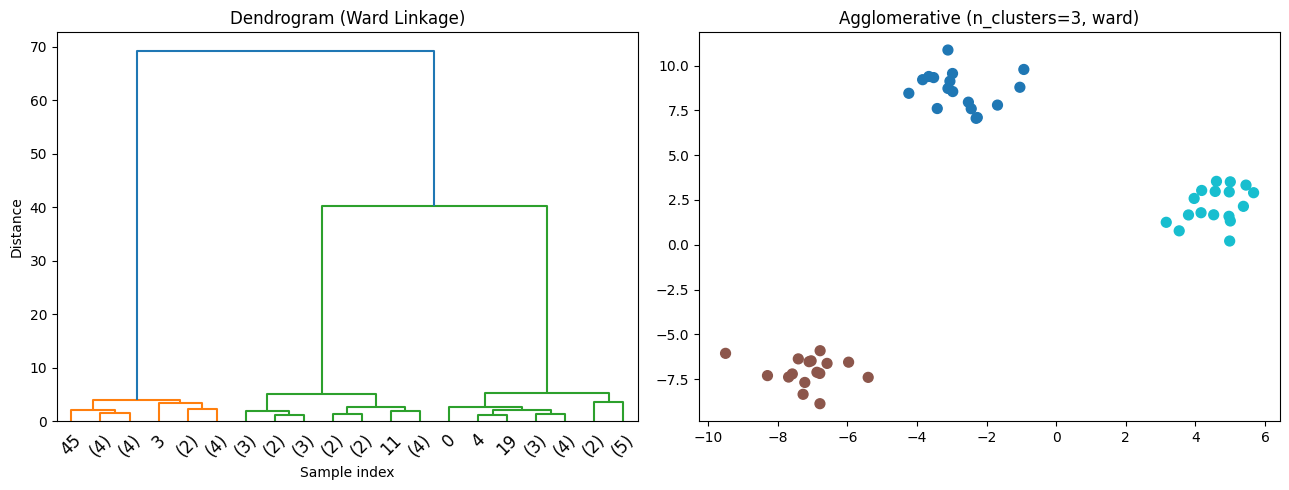

In [557]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Agglomerative clustering — merges nearest clusters bottom-up
X_agg, _ = make_blobs(n_samples=50, centers=3, random_state=42)

# Dendrogram to visualise merge order
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
Z = linkage(X_agg, method='ward')

from scipy.cluster.hierarchy import dendrogram
dendrogram(Z, ax=axes[0], truncate_mode='lastp', p=20, leaf_rotation=45)
axes[0].set_title('Dendrogram (Ward Linkage)')
axes[0].set_xlabel('Sample index')
axes[0].set_ylabel('Distance')

# Flat cut
agg = AgglomerativeClustering(n_clusters=3, linkage='ward')
agg_labels = agg.fit_predict(X_agg)
axes[1].scatter(X_agg[:,0], X_agg[:,1], c=agg_labels, cmap='tab10', s=50)
axes[1].set_title('Agglomerative (n_clusters=3, ward)')

plt.tight_layout()
plt.savefig('hierarchical.png', dpi=100, bbox_inches='tight')
plt.show()


## Module 13 — Dimensionality Reduction

### 13.1 Principal Component Analysis (PCA)

PCA finds **orthogonal axes** (principal components) that capture maximum variance.  
Use cases: visualisation, noise reduction, speeding up downstream models.


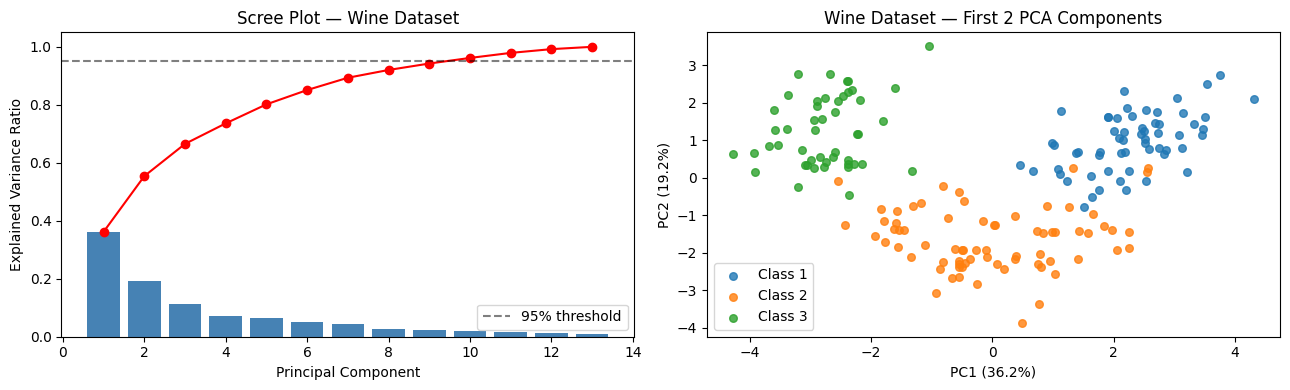

Components needed for 95% variance: 10 out of 13


In [558]:
from sklearn.decomposition import PCA, TruncatedSVD, NMF
from sklearn.manifold import TSNE

X_wine, y_wine = load_wine(return_X_y=True)
X_wine_s = StandardScaler().fit_transform(X_wine)

# Scree plot — explained variance ratio
pca_full = PCA().fit(X_wine_s)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(range(1, len(pca_full.explained_variance_ratio_)+1),
             pca_full.explained_variance_ratio_, color='steelblue')
axes[0].plot(range(1, len(pca_full.explained_variance_ratio_)+1),
              np.cumsum(pca_full.explained_variance_ratio_), 'ro-', lw=1.5)
axes[0].axhline(0.95, color='k', linestyle='--', alpha=0.5, label='95% threshold')
axes[0].set_xlabel('Principal Component'); axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Scree Plot — Wine Dataset')
axes[0].legend()

# 2D PCA projection
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_wine_s)

for cls in np.unique(y_wine):
    mask = y_wine == cls
    axes[1].scatter(X_pca_2d[mask,0], X_pca_2d[mask,1],
                     label=f'Class {cls+1}', s=30, alpha=0.8)
axes[1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].set_title('Wine Dataset — First 2 PCA Components')
axes[1].legend()

plt.tight_layout()
plt.savefig('pca.png', dpi=100, bbox_inches='tight')
plt.show()

n_for_95 = np.searchsorted(np.cumsum(pca_full.explained_variance_ratio_), 0.95) + 1
print(f"Components needed for 95% variance: {n_for_95} out of {X_wine_s.shape[1]}")


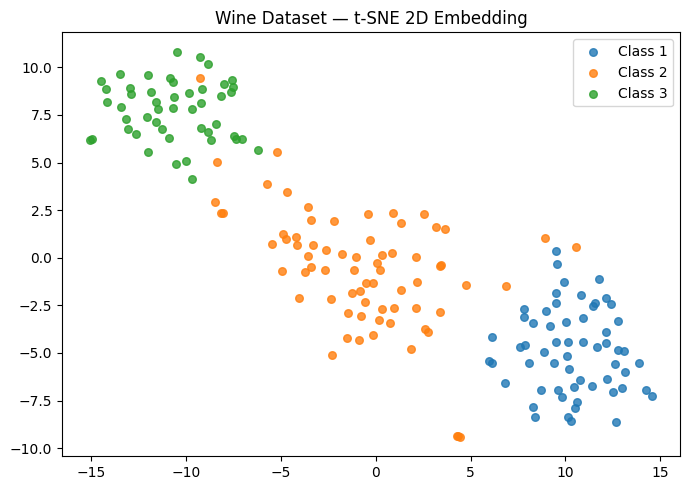

In [559]:
# t-SNE — non-linear 2D visualisation (exploration only, not for modeling)
tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42)
X_tsne = tsne.fit_transform(X_wine_s)

plt.figure(figsize=(7, 5))
for cls in np.unique(y_wine):
    mask = y_wine == cls
    plt.scatter(X_tsne[mask,0], X_tsne[mask,1], label=f'Class {cls+1}', s=30, alpha=0.8)
plt.title('Wine Dataset — t-SNE 2D Embedding')
plt.legend()
plt.tight_layout()
plt.savefig('tsne.png', dpi=100, bbox_inches='tight')
plt.show()


## Module 14 — Feature Selection

### 14.1 Filter Methods

Filter methods rank features **independently of the model** using statistical tests.

| Method | Function | Best for |
|--------|----------|----------|
| Chi-squared | `chi2` | Classification, non-negative features |
| ANOVA F-test | `f_classif` | Classification, numeric features |
| Mutual Info | `mutual_info_classif` | Non-linear relationships |
| Correlation | `f_regression` | Regression |


In [560]:
from sklearn.feature_selection import (SelectKBest, chi2, f_classif,
                                       mutual_info_classif, f_regression,
                                       SelectPercentile, VarianceThreshold,
                                       RFE, RFECV, SelectFromModel)

X, y = load_breast_cancer(return_X_y=True)
feature_names = load_breast_cancer().feature_names

# ANOVA F-test
selector_f = SelectKBest(f_classif, k=10)
selector_f.fit(X, y)

scores_df = pd.DataFrame({
    'feature': feature_names,
    'f_score': selector_f.scores_,
    'p_value': selector_f.pvalues_
}).sort_values('f_score', ascending=False)

print("Top 10 features by ANOVA F-score:")
print(scores_df.head(10).to_string(index=False))


Top 10 features by ANOVA F-score:
             feature    f_score       p_value
worst concave points 964.385393 1.969100e-124
     worst perimeter 897.944219 5.771397e-119
 mean concave points 861.676020 7.101150e-116
        worst radius 860.781707 8.482292e-116
      mean perimeter 697.235272 8.436251e-101
          worst area 661.600206  2.828848e-97
         mean radius 646.981021  8.465941e-96
           mean area 573.060747  4.734564e-88
      mean concavity 533.793126  9.966556e-84
     worst concavity 436.691939  2.464664e-72


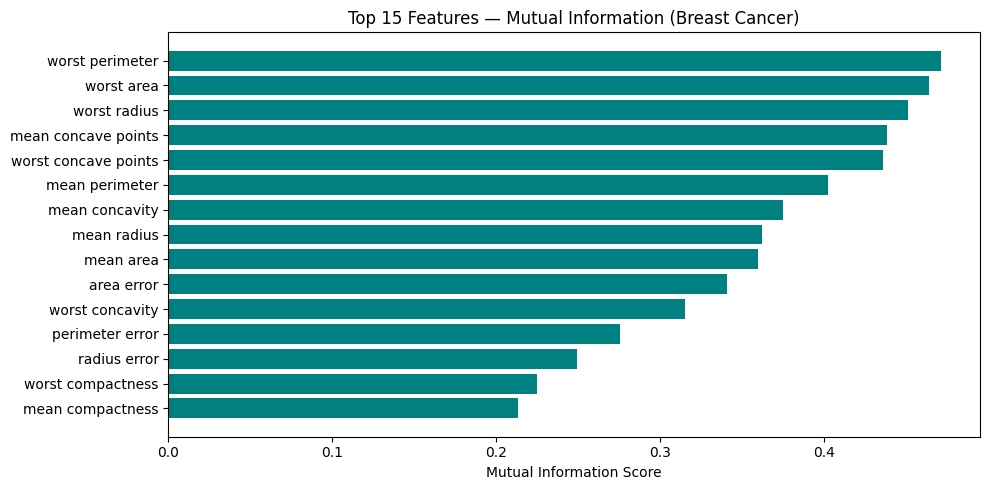

In [561]:
# Mutual Information
mi_scores = mutual_info_classif(X, y, random_state=42)
mi_df = pd.DataFrame({'feature': feature_names, 'mi_score': mi_scores})
mi_df = mi_df.sort_values('mi_score', ascending=False)

plt.figure(figsize=(10, 5))
plt.barh(mi_df['feature'][:15], mi_df['mi_score'][:15], color='teal')
plt.xlabel('Mutual Information Score')
plt.title('Top 15 Features — Mutual Information (Breast Cancer)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('mutual_info.png', dpi=100, bbox_inches='tight')
plt.show()


### 14.2 Wrapper Methods — Recursive Feature Elimination (RFE)


In [562]:
from sklearn.feature_selection import RFE, RFECV

# RFE — recursively remove least important features
rfe = RFE(estimator=LogisticRegression(max_iter=5000), n_features_to_select=10)
X_s = StandardScaler().fit_transform(X)
rfe.fit(X_s, y)

selected = feature_names[rfe.support_]
print("RFE-selected features (10):")
for rank, name in sorted(zip(rfe.ranking_, feature_names)):
    marker = "  *** SELECTED" if rank == 1 else ""
    print(f"  Rank {rank:2d}: {name}{marker}")


RFE-selected features (10):
  Rank  1: area error  *** SELECTED
  Rank  1: compactness error  *** SELECTED
  Rank  1: mean concave points  *** SELECTED
  Rank  1: radius error  *** SELECTED
  Rank  1: worst area  *** SELECTED
  Rank  1: worst concave points  *** SELECTED
  Rank  1: worst concavity  *** SELECTED
  Rank  1: worst perimeter  *** SELECTED
  Rank  1: worst radius  *** SELECTED
  Rank  1: worst texture  *** SELECTED
  Rank  2: worst smoothness
  Rank  3: mean area
  Rank  4: perimeter error
  Rank  5: mean compactness
  Rank  6: worst symmetry
  Rank  7: mean radius
  Rank  8: mean concavity
  Rank  9: mean texture
  Rank 10: mean perimeter
  Rank 11: fractal dimension error
  Rank 12: symmetry error
  Rank 13: smoothness error
  Rank 14: worst fractal dimension
  Rank 15: mean fractal dimension
  Rank 16: concave points error
  Rank 17: texture error
  Rank 18: mean smoothness
  Rank 19: concavity error
  Rank 20: mean symmetry
  Rank 21: worst compactness


### 14.3 Embedded Methods — SelectFromModel


In [563]:
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier

# Use a fitted model's feature_importances_ to select
rf_sel = RandomForestClassifier(n_estimators=200, random_state=42)
sfm = SelectFromModel(rf_sel, threshold='mean')  # keep features above mean importance
sfm.fit(X, y)

X_selected = sfm.transform(X)
selected_mask = sfm.get_support()
print(f"Original features : {X.shape[1]}")
print(f"Selected features : {X_selected.shape[1]}")
print("Selected feature names:")
print(feature_names[selected_mask])


Original features : 30
Selected features : 10
Selected feature names:
['mean radius' 'mean perimeter' 'mean area' 'mean concavity'
 'mean concave points' 'worst radius' 'worst perimeter' 'worst area'
 'worst concavity' 'worst concave points']


## Module 15 — Handling Imbalanced Classes

### 15.1 class_weight Parameter

Many sklearn classifiers accept `class_weight='balanced'`  
which automatically upweights minority classes.


In [564]:
from sklearn.datasets import make_classification
from sklearn.metrics import classification_report

# Simulate imbalanced data (90:10 ratio)
X_imb, y_imb = make_classification(n_samples=1000, n_features=10,
                                     weights=[0.9, 0.1],
                                     random_state=42, n_informative=5)

X_im_tr, X_im_te, y_im_tr, y_im_te = train_test_split(
    X_imb, y_imb, test_size=0.2, stratify=y_imb, random_state=42)

print(f"Class distribution — Train: {np.bincount(y_im_tr)},  Test: {np.bincount(y_im_te)}")

# Without class_weight
lr_plain = LogisticRegression(max_iter=1000)
lr_plain.fit(X_im_tr, y_im_tr)
print("\n=== Without class_weight ===")
print(classification_report(y_im_te, lr_plain.predict(X_im_te)))

# With class_weight='balanced'
lr_balanced = LogisticRegression(max_iter=1000, class_weight='balanced')
lr_balanced.fit(X_im_tr, y_im_tr)
print("\n=== With class_weight='balanced' ===")
print(classification_report(y_im_te, lr_balanced.predict(X_im_te)))


Class distribution — Train: [717  83],  Test: [179  21]

=== Without class_weight ===
              precision    recall  f1-score   support

           0       0.91      0.99      0.95       179
           1       0.67      0.19      0.30        21

    accuracy                           0.91       200
   macro avg       0.79      0.59      0.62       200
weighted avg       0.89      0.91      0.88       200


=== With class_weight='balanced' ===
              precision    recall  f1-score   support

           0       0.97      0.77      0.86       179
           1       0.29      0.81      0.42        21

    accuracy                           0.77       200
   macro avg       0.63      0.79      0.64       200
weighted avg       0.90      0.77      0.81       200



### 15.2 Threshold Adjustment

The default decision threshold is 0.5. Lowering it increases recall (catches more positives)  
at the cost of more false positives.


Default (0.5) F1  : 0.4250
Best threshold    : 0.54
Best F1           : 0.4595


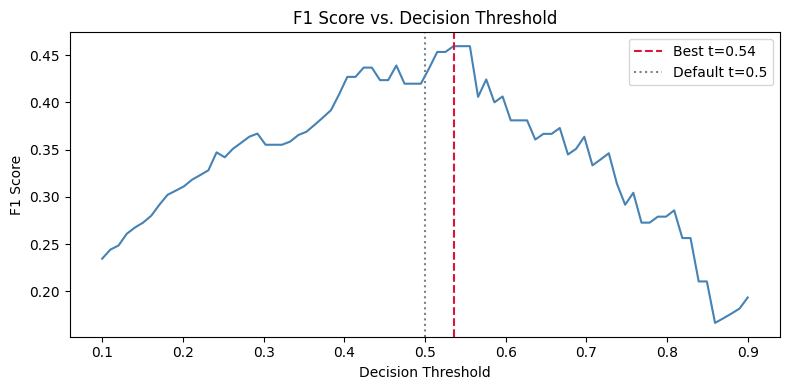

In [565]:
# Find threshold that maximises F1 score
from sklearn.metrics import f1_score

lr_balanced.fit(X_im_tr, y_im_tr)
y_proba = lr_balanced.predict_proba(X_im_te)[:, 1]

thresholds = np.linspace(0.1, 0.9, 80)
f1_scores = [f1_score(y_im_te, (y_proba >= t).astype(int)) for t in thresholds]

best_t = thresholds[np.argmax(f1_scores)]
print(f"Default (0.5) F1  : {f1_score(y_im_te, (y_proba >= 0.5).astype(int)):.4f}")
print(f"Best threshold    : {best_t:.2f}")
print(f"Best F1           : {max(f1_scores):.4f}")

plt.figure(figsize=(8, 4))
plt.plot(thresholds, f1_scores, color='steelblue')
plt.axvline(best_t, color='crimson', linestyle='--', label=f'Best t={best_t:.2f}')
plt.axvline(0.5, color='grey', linestyle=':', label='Default t=0.5')
plt.xlabel('Decision Threshold'); plt.ylabel('F1 Score')
plt.title('F1 Score vs. Decision Threshold')
plt.legend()
plt.tight_layout()
plt.savefig('threshold.png', dpi=100, bbox_inches='tight')
plt.show()


## Module 16 — Model Persistence

### 16.1 Saving and Loading Models with `joblib`

`joblib` is the preferred way to serialize sklearn objects —  
it is more efficient than `pickle` for large numpy arrays.


In [566]:
import joblib
import os

# Train a full pipeline
X, y = load_breast_cancer(return_X_y=True)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

production_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  RandomForestClassifier(n_estimators=100, random_state=42))
])
production_pipe.fit(X_tr, y_tr)

# Save the model
model_path = 'breast_cancer_pipeline.joblib'
joblib.dump(production_pipe, model_path)
print(f"Model saved to: {model_path}")
print(f"File size     : {os.path.getsize(model_path) / 1024:.1f} KB")

# Load and use the model
loaded_pipe = joblib.load(model_path)
score = loaded_pipe.score(X_te, y_te)
print(f"Loaded model test accuracy: {score:.4f}")

# Verify they are identical
original_preds = production_pipe.predict(X_te)
loaded_preds   = loaded_pipe.predict(X_te)
print(f"Predictions identical: {np.array_equal(original_preds, loaded_preds)}")


Model saved to: breast_cancer_pipeline.joblib
File size     : 318.8 KB
Loaded model test accuracy: 0.9649
Predictions identical: True


In [567]:
# Versioning best practice — save with metadata
import json
from datetime import datetime

model_metadata = {
    'model_type'      : 'RandomForestClassifier',
    'n_estimators'    : 100,
    'train_accuracy'  : round(production_pipe.score(X_tr, y_tr), 4),
    'test_accuracy'   : round(score, 4),
    'n_features'      : X_tr.shape[1],
    'n_training_samples': X_tr.shape[0],
    'feature_names'   : list(load_breast_cancer().feature_names),
    'trained_at'      : datetime.now().isoformat()
}

metadata_path = 'breast_cancer_metadata.json'
with open(metadata_path, 'w') as f:
    json.dump(model_metadata, f, indent=2)

print("Model metadata:")
print(json.dumps(model_metadata, indent=2))


Model metadata:
{
  "model_type": "RandomForestClassifier",
  "n_estimators": 100,
  "train_accuracy": 1.0,
  "test_accuracy": 0.9649,
  "n_features": 30,
  "n_training_samples": 455,
  "feature_names": [
    "mean radius",
    "mean texture",
    "mean perimeter",
    "mean area",
    "mean smoothness",
    "mean compactness",
    "mean concavity",
    "mean concave points",
    "mean symmetry",
    "mean fractal dimension",
    "radius error",
    "texture error",
    "perimeter error",
    "area error",
    "smoothness error",
    "compactness error",
    "concavity error",
    "concave points error",
    "symmetry error",
    "fractal dimension error",
    "worst radius",
    "worst texture",
    "worst perimeter",
    "worst area",
    "worst smoothness",
    "worst compactness",
    "worst concavity",
    "worst concave points",
    "worst symmetry",
    "worst fractal dimension"
  ],
  "trained_at": "2026-06-02T10:29:58.027938"
}


## Module 17 — Custom Estimators

### 17.1 Building Your Own Sklearn-Compatible Transformer

To build a custom transformer that works inside a Pipeline:
1. Inherit from `BaseEstimator` and `TransformerMixin`
2. Implement `fit(self, X, y=None)` — must return `self`
3. Implement `transform(self, X)` — returns transformed X
4. `fit_transform` is provided automatically by `TransformerMixin`


In [568]:
from sklearn.base import BaseEstimator, TransformerMixin, ClassifierMixin
import numpy as np

class OutlierClipper(BaseEstimator, TransformerMixin):
    """
    Clips feature values to [mean - n_std * std, mean + n_std * std].
    Learned parameters: clip_min_, clip_max_ (one per feature).
    """
    def __init__(self, n_std=3.0):
        self.n_std = n_std

    def fit(self, X, y=None):
        X = np.array(X)
        self.clip_min_ = X.mean(axis=0) - self.n_std * X.std(axis=0)
        self.clip_max_ = X.mean(axis=0) + self.n_std * X.std(axis=0)
        return self  # always return self

    def transform(self, X):
        X = np.array(X)
        return np.clip(X, self.clip_min_, self.clip_max_)


# Test it
X_test_oc = np.array([[1, 2], [3, 4], [100, 200], [2, 3], [-50, 1]])
oc = OutlierClipper(n_std=1.5)
X_clipped = oc.fit_transform(X_test_oc)

print("Original:")
print(X_test_oc)
print("\nAfter OutlierClipper(n_std=1.5):")
print(X_clipped.round(2))
print("\nLearned clip_min_:", oc.clip_min_.round(2))
print("Learned clip_max_:", oc.clip_max_.round(2))


Original:
[[  1   2]
 [  3   4]
 [100 200]
 [  2   3]
 [-50   1]]

After OutlierClipper(n_std=1.5):
[[  1.     2.  ]
 [  3.     4.  ]
 [ 84.34 160.51]
 [  2.     3.  ]
 [-50.     1.  ]]

Learned clip_min_: [-61.94 -76.51]
Learned clip_max_: [ 84.34 160.51]


In [569]:
# Verify it works inside a sklearn Pipeline
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

X, y = load_breast_cancer(return_X_y=True)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

custom_pipe = Pipeline([
    ('clipper', OutlierClipper(n_std=3.0)),
    ('scaler',  StandardScaler()),
    ('model',   LogisticRegression(max_iter=1000))
])

custom_pipe.fit(X_tr, y_tr)
print("Custom pipeline accuracy:", round(custom_pipe.score(X_te, y_te), 4))

# Works with cross-validation too
cv_s = cross_val_score(custom_pipe, X, y, cv=5, scoring='accuracy')
print(f"CV accuracy: {cv_s.mean():.4f} ± {cv_s.std():.4f}")

# Works with GridSearchCV — note the 'clipper__' prefix
param_grid_custom = {
    'clipper__n_std': [2.0, 2.5, 3.0, 3.5],
    'model__C'      : [0.01, 0.1, 1.0, 10.0],
}
gs = GridSearchCV(custom_pipe, param_grid_custom, cv=5, scoring='accuracy', n_jobs=-1)
gs.fit(X_tr, y_tr)
print("\nBest params  :", gs.best_params_)
print("Best CV acc  :", round(gs.best_score_, 4))


Custom pipeline accuracy: 0.9825
CV accuracy: 0.9824 ± 0.0078

Best params  : {'clipper__n_std': 2.0, 'model__C': 1.0}
Best CV acc  : 0.9758


### 17.2 Custom Classifier


In [570]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.utils.validation import check_X_y, check_array, check_is_fitted
from sklearn.utils.multiclass import unique_labels

class MedianThresholdClassifier(BaseEstimator, ClassifierMixin):
    """
    Classifies based on whether the first feature exceeds its training median.
    A toy example to illustrate the full classifier interface.
    """
    def __init__(self, feature_index=0):
        self.feature_index = feature_index

    def fit(self, X, y):
        X, y = check_X_y(X, y)
        self.classes_ = unique_labels(y)
        self.threshold_ = np.median(X[:, self.feature_index])
        self.is_fitted_ = True
        return self

    def predict(self, X):
        check_is_fitted(self, 'is_fitted_')
        X = check_array(X)
        return (X[:, self.feature_index] >= self.threshold_).astype(int)

    def score(self, X, y):
        return accuracy_score(y, self.predict(X))


X, y = load_breast_cancer(return_X_y=True)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

mtc = MedianThresholdClassifier(feature_index=0)
mtc.fit(X_tr, y_tr)
print(f"MedianThresholdClassifier accuracy: {mtc.score(X_te, y_te):.4f}")
print(f"Learned threshold: {mtc.threshold_:.4f}")


MedianThresholdClassifier accuracy: 0.1579
Learned threshold: 13.3000


## Module 18 — End-to-End Project

### 18.1 Project: Predicting Loan Default Risk

In this end-to-end project we build a production-ready pipeline on a realistic  
synthetic banking dataset, mimicking the kind of problem encountered in Nigerian  
commercial banking.

**Problem Statement:** Predict whether a loan applicant will default (1) or not (0).  

**Workflow:**
1. Generate and inspect dataset
2. Exploratory Data Analysis
3. Build a full preprocessing pipeline
4. Train and compare multiple models
5. Hyperparameter tuning on the best model
6. Final evaluation on holdout test set
7. Feature importance and model interpretation
8. Save the production pipeline


In [571]:
# Step 1 — Generate a realistic synthetic banking dataset
np.random.seed(2024)
n = 2000

credit_scores = np.random.normal(650, 80, n).clip(300, 850)
# Lower credit score → higher default probability
default_prob = 1 / (1 + np.exp((credit_scores - 600) / 50))

df_loan = pd.DataFrame({
    'age'             : np.random.randint(22, 65, n),
    'annual_income'   : np.random.lognormal(11.5, 0.5, n).clip(100000, 5000000),
    'credit_score'    : credit_scores.astype(int),
    'loan_amount'     : np.random.randint(50000, 2000000, n),
    'loan_term_months': np.random.choice([12, 24, 36, 48, 60], n),
    'employment_years': np.random.exponential(5, n).clip(0, 30).round(1),
    'debt_to_income'  : np.random.beta(2, 5, n),
    'num_open_accounts': np.random.randint(1, 10, n),
    'delinquencies'   : np.random.poisson(0.5, n),
    'purpose'         : np.random.choice(['business', 'personal', 'education', 'vehicle'], n,
                                          p=[0.4, 0.3, 0.2, 0.1]),
    'state'           : np.random.choice(['Lagos', 'Abuja', 'Kano', 'Rivers', 'Ogun'], n),
    'employment_type' : np.random.choice(['salaried', 'self_employed', 'contract'], n,
                                          p=[0.55, 0.35, 0.10]),
})

# Introduce missing values
for col in ['employment_years', 'debt_to_income', 'num_open_accounts']:
    df_loan.loc[np.random.choice(n, int(n*0.05), replace=False), col] = np.nan

df_loan['default'] = (np.random.random(n) < default_prob).astype(int)

print("Dataset shape :", df_loan.shape)
print("Default rate  :", df_loan['default'].mean().round(3))
print("\nFirst 5 rows:")
df_loan.head()


Dataset shape : (2000, 13)
Default rate  : 0.33

First 5 rows:


,age,annual_income,credit_score,loan_amount,loan_term_months,employment_years,debt_to_income,num_open_accounts,delinquencies,purpose,state,employment_type,default
0,33,100000.000000,783,1996608,12,1.3,0.639241,5.0,1,education,Abuja,self_employed,0
1,57,100000.000000,708,1088866,60,NaN,0.357755,7.0,1,business,Kano,contract,0
2,45,100000.000000,633,1134826,48,0.6,0.193172,8.0,0,personal,Lagos,self_employed,1
3,29,174091.767841,637,781506,12,7.4,0.175667,3.0,0,business,Rivers,salaried,1
4,32,215250.247092,723,1996769,12,10.9,0.247615,9.0,0,business,Abuja,self_employed,0


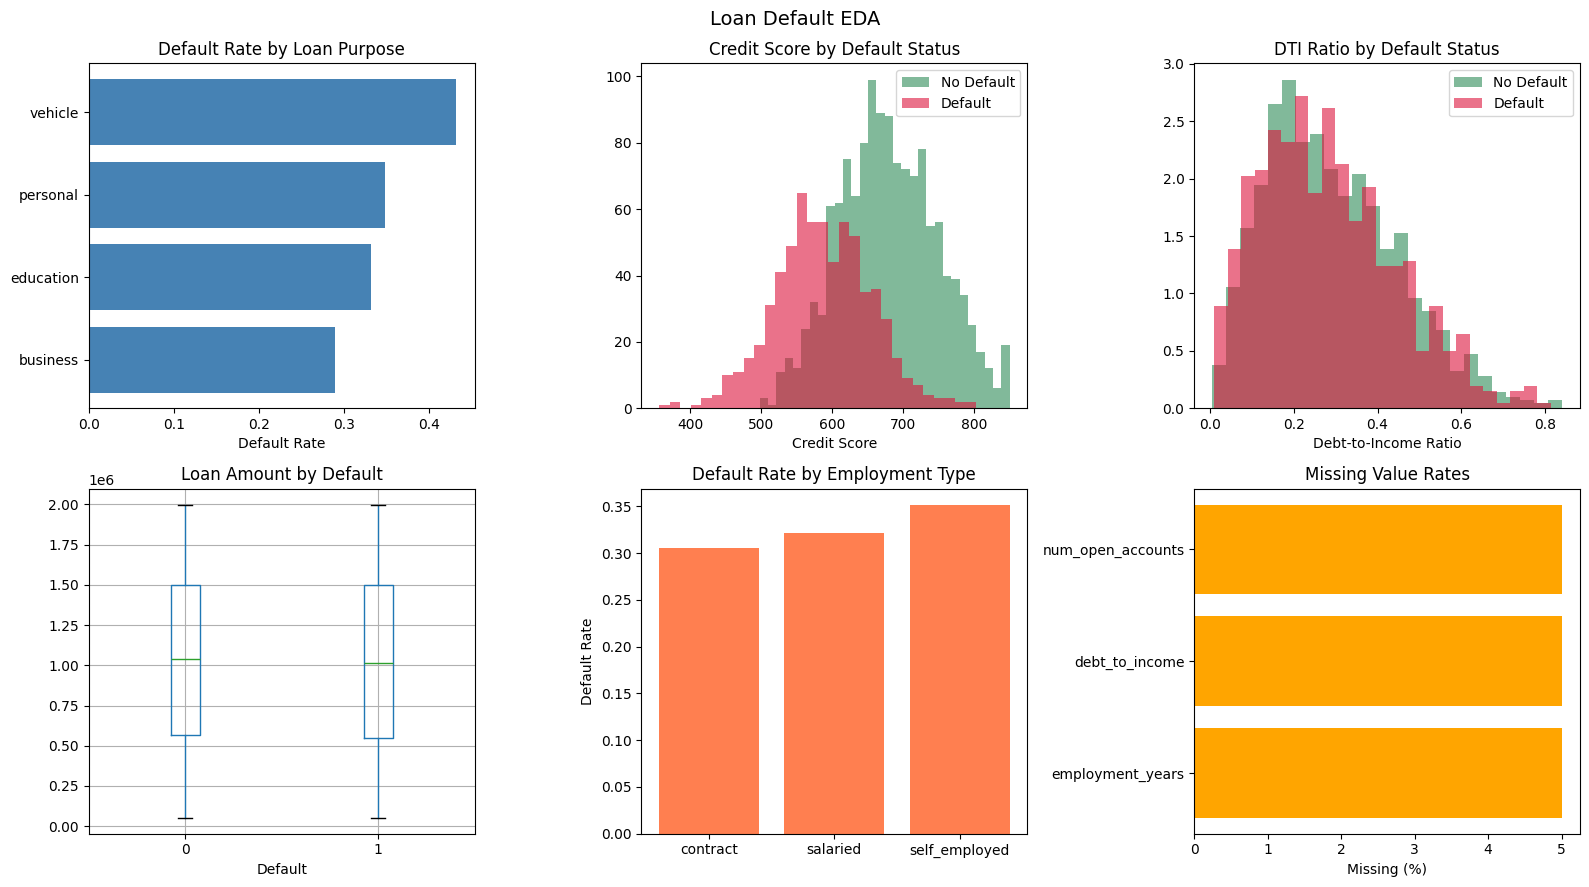

In [572]:
# Step 2 — EDA
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Default rate by purpose
default_by_purpose = df_loan.groupby('purpose')['default'].mean().sort_values()
axes[0,0].barh(default_by_purpose.index, default_by_purpose.values, color='steelblue')
axes[0,0].set_xlabel('Default Rate'); axes[0,0].set_title('Default Rate by Loan Purpose')

# Credit score distribution
for cls, lbl, col in zip([0,1], ['No Default', 'Default'], ['seagreen','crimson']):
    axes[0,1].hist(df_loan[df_loan['default']==cls]['credit_score'],
                    bins=30, alpha=0.6, label=lbl, color=col)
axes[0,1].set_xlabel('Credit Score'); axes[0,1].legend()
axes[0,1].set_title('Credit Score by Default Status')

# DTI ratio
for cls, lbl, col in zip([0,1], ['No Default', 'Default'], ['seagreen','crimson']):
    axes[0,2].hist(df_loan[df_loan['default']==cls]['debt_to_income'].dropna(),
                    bins=25, alpha=0.6, label=lbl, color=col, density=True)
axes[0,2].set_xlabel('Debt-to-Income Ratio'); axes[0,2].legend()
axes[0,2].set_title('DTI Ratio by Default Status')

# Loan amount
df_loan.boxplot(column='loan_amount', by='default', ax=axes[1,0])
axes[1,0].set_title('Loan Amount by Default'); axes[1,0].set_xlabel('Default')

# Default rate by employment type
axes[1,1].bar(
    df_loan.groupby('employment_type')['default'].mean().index,
    df_loan.groupby('employment_type')['default'].mean().values,
    color='coral'
)
axes[1,1].set_ylabel('Default Rate'); axes[1,1].set_title('Default Rate by Employment Type')

# Missing values
missing = df_loan.isnull().mean() * 100
missing = missing[missing > 0]
axes[1,2].barh(missing.index, missing.values, color='orange')
axes[1,2].set_xlabel('Missing (%)'); axes[1,2].set_title('Missing Value Rates')

plt.suptitle('Loan Default EDA', fontsize=14)
plt.tight_layout()
plt.savefig('eda.png', dpi=100, bbox_inches='tight')
plt.show()


In [573]:
# Step 3 — Full Preprocessing Pipeline
from sklearn.compose import ColumnTransformer

X_loan = df_loan.drop('default', axis=1)
y_loan = df_loan['default']

X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
    X_loan, y_loan, test_size=0.2, stratify=y_loan, random_state=42)

num_features = ['age', 'annual_income', 'credit_score', 'loan_amount',
                 'loan_term_months', 'employment_years', 'debt_to_income',
                 'num_open_accounts', 'delinquencies']
cat_features = ['purpose', 'state', 'employment_type']

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe',     OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)
])

print("Preprocessing pipeline built.")
print("Numeric features  :", num_features)
print("Categorical features:", cat_features)


Preprocessing pipeline built.
Numeric features  : ['age', 'annual_income', 'credit_score', 'loan_amount', 'loan_term_months', 'employment_years', 'debt_to_income', 'num_open_accounts', 'delinquencies']
Categorical features: ['purpose', 'state', 'employment_type']


In [574]:
# Step 4 — Train and compare multiple models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               ExtraTreesClassifier)
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score, f1_score, classification_report

model_zoo = {
    'LogisticRegression'  : LogisticRegression(max_iter=2000, class_weight='balanced'),
    'RandomForest'        : RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1),
    'ExtraTrees'          : ExtraTreesClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1),
    'GradientBoosting'    : GradientBoostingClassifier(n_estimators=100, random_state=42),
}

print(f"{'Model':<24}  {'CV AUC':>8}  {'CV F1':>7}  {'Test AUC':>9}  {'Test F1':>8}")
print("-"*65)

best_auc, best_model_name = 0, None
for name, clf in model_zoo.items():
    pipe = Pipeline([('pre', preprocessor), ('clf', clf)])
    
    cv_auc = cross_val_score(pipe, X_train_l, y_train_l,
                              cv=StratifiedKFold(5, shuffle=True, random_state=42),
                              scoring='roc_auc', n_jobs=-1).mean()
    cv_f1  = cross_val_score(pipe, X_train_l, y_train_l,
                              cv=StratifiedKFold(5, shuffle=True, random_state=42),
                              scoring='f1', n_jobs=-1).mean()
    
    pipe.fit(X_train_l, y_train_l)
    te_auc = roc_auc_score(y_test_l, pipe.predict_proba(X_test_l)[:,1])
    te_f1  = f1_score(y_test_l, pipe.predict(X_test_l))
    
    marker = "  <-- BEST" if te_auc > best_auc else ""
    if te_auc > best_auc:
        best_auc = te_auc
        best_model_name = name
    
    print(f"{name:<24}  {cv_auc:>8.4f}  {cv_f1:>7.4f}  {te_auc:>9.4f}  {te_f1:>8.4f}{marker}")

print(f"\nBest model: {best_model_name}")


Model                       CV AUC    CV F1   Test AUC   Test F1
-----------------------------------------------------------------
LogisticRegression          0.8157   0.6372     0.8536    0.7016  <-- BEST
RandomForest                0.7936   0.5535     0.8447    0.6307
ExtraTrees                  0.7645   0.4747     0.8241    0.5810
GradientBoosting            0.7946   0.5771     0.8334    0.6559

Best model: LogisticRegression


In [575]:
# Step 5 — Hyperparameter Tuning on GradientBoosting
from scipy.stats import randint, loguniform

final_pipe = Pipeline([
    ('pre', preprocessor),
    ('clf', GradientBoostingClassifier(random_state=42))
])

param_dist_gb = {
    'clf__n_estimators'  : randint(100, 400),
    'clf__learning_rate' : loguniform(0.01, 0.3),
    'clf__max_depth'     : randint(2, 6),
    'clf__min_samples_leaf': randint(5, 30),
    'clf__subsample'     : [0.7, 0.8, 0.9, 1.0],
}

rs = RandomizedSearchCV(
    final_pipe,
    param_distributions=param_dist_gb,
    n_iter=20,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42,
    verbose=0
)
rs.fit(X_train_l, y_train_l)

print("Best parameters :")
for k, v in rs.best_params_.items():
    val = round(v, 4) if isinstance(v, float) else v
    print(f"  {k}: {val}")
print(f"\nBest CV AUC   : {rs.best_score_:.4f}")


Best parameters :
  clf__learning_rate: 0.0175
  clf__max_depth: 2
  clf__min_samples_leaf: 11
  clf__n_estimators: 108
  clf__subsample: 1.0

Best CV AUC   : 0.8149


=== FINAL MODEL EVALUATION — Holdout Test Set ===
ROC-AUC  : 0.8572
F1 Score : 0.6838
Accuracy : 0.8150

              precision    recall  f1-score   support

  No Default       0.83      0.92      0.87       268
     Default       0.78      0.61      0.68       132

    accuracy                           0.81       400
   macro avg       0.80      0.76      0.78       400
weighted avg       0.81      0.81      0.81       400



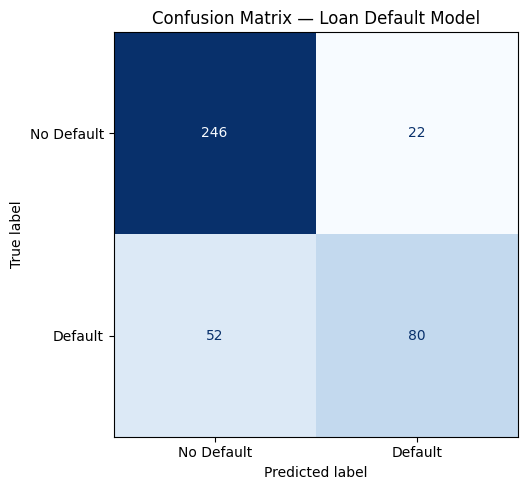

In [576]:
# Step 6 — Final evaluation on holdout test set
best_pipeline = rs.best_estimator_
y_pred_final  = best_pipeline.predict(X_test_l)
y_prob_final  = best_pipeline.predict_proba(X_test_l)[:,1]

print("=== FINAL MODEL EVALUATION — Holdout Test Set ===")
print(f"ROC-AUC  : {roc_auc_score(y_test_l, y_prob_final):.4f}")
print(f"F1 Score : {f1_score(y_test_l, y_pred_final):.4f}")
print(f"Accuracy : {accuracy_score(y_test_l, y_pred_final):.4f}")
print()
print(classification_report(y_test_l, y_pred_final,
                              target_names=['No Default', 'Default']))

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test_l, y_pred_final)
disp = ConfusionMatrixDisplay(cm, display_labels=['No Default', 'Default'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Loan Default Model')
plt.tight_layout()
plt.savefig('final_cm.png', dpi=100, bbox_inches='tight')
plt.show()


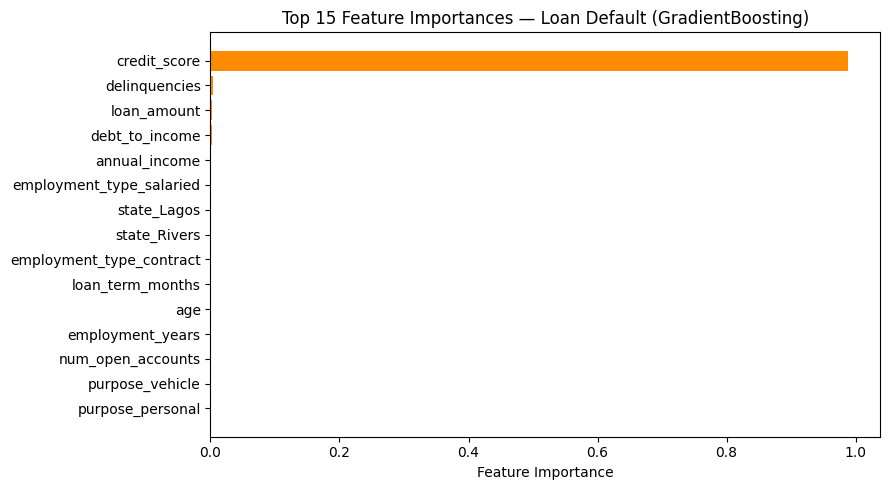

In [577]:
# Step 7 — Feature importance from the final model
clf_step = best_pipeline.named_steps['clf']
pre_step = best_pipeline.named_steps['pre']

# Reconstruct feature names
num_names = num_features
cat_names = list(pre_step.named_transformers_['cat']['ohe']
                  .get_feature_names_out(cat_features))
all_names = num_names + cat_names

importances = clf_step.feature_importances_
imp_df = pd.DataFrame({'feature': all_names, 'importance': importances})
imp_df = imp_df.sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(9, 5))
plt.barh(imp_df['feature'], imp_df['importance'], color='darkorange')
plt.xlabel('Feature Importance')
plt.title('Top 15 Feature Importances — Loan Default (GradientBoosting)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('final_importances.png', dpi=100, bbox_inches='tight')
plt.show()


In [578]:
# Step 8 — Save the production pipeline
import joblib, json
from datetime import datetime

model_path = 'loan_default_pipeline_v1.joblib'
joblib.dump(best_pipeline, model_path)

metadata = {
    'project'       : 'Loan Default Prediction',
    'version'       : '1.0',
    'algorithm'     : 'GradientBoostingClassifier',
    'test_roc_auc'  : round(roc_auc_score(y_test_l, y_prob_final), 4),
    'test_f1'       : round(f1_score(y_test_l, y_pred_final), 4),
    'test_accuracy' : round(accuracy_score(y_test_l, y_pred_final), 4),
    'n_features'    : len(num_features) + len(cat_features),
    'trained_on'    : datetime.now().isoformat(),
    'best_params'   : {k: (round(v,5) if isinstance(v, float) else v)
                       for k, v in rs.best_params_.items()}
}

with open('loan_default_metadata_v1.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("Production pipeline saved.")
print(json.dumps(metadata, indent=2))


Production pipeline saved.
{
  "project": "Loan Default Prediction",
  "version": "1.0",
  "algorithm": "GradientBoostingClassifier",
  "test_roc_auc": 0.8572,
  "test_f1": 0.6838,
  "test_accuracy": 0.815,
  "n_features": 12,
  "trained_on": "2026-06-02T10:31:01.350929",
  "best_params": {
    "clf__learning_rate": 0.01754,
    "clf__max_depth": 2,
    "clf__min_samples_leaf": 11,
    "clf__n_estimators": 108,
    "clf__subsample": 1.0
  }
}


In [ ]:
# Inference on a new applicant
new_applicant = pd.DataFrame([{
    'age'              : 34,
    'annual_income'    : 850000,
    'credit_score'     : 580,
    'loan_amount'      : 500000,
    'loan_term_months' : 36,
    'employment_years' : 2.5,
    'debt_to_income'   : 0.42,
    'num_open_accounts': 4,
    'delinquencies'    : 2,
    'purpose'          : 'business',
    'state'            : 'Lagos',
    'employment_type'  : 'self_employed',
}])

loaded = joblib.load(model_path)
default_prob = loaded.predict_proba(new_applicant)[0, 1]
decision     = loaded.predict(new_applicant)[0]

print("=== LOAN APPLICATION DECISION ===")
print(f"Applicant profile loaded: ✓")
print(f"Default probability : {default_prob:.4f}  ({default_prob*100:.1f}%)")
print(f"Decision            : {'DECLINE — HIGH RISK' if decision == 1 else 'APPROVE — LOW RISK'}")


=== LOAN APPLICATION DECISION ===
Applicant profile loaded: ✓
Default probability : 0.5092  (50.9%)
Decision            : DECLINE — HIGH RISK


: 

## Appendix — Quick Reference

### The Sklearn Estimator Cheat Sheet

```
from sklearn.linear_model    import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.svm              import SVC, SVR
from sklearn.tree             import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble         import (RandomForestClassifier, RandomForestRegressor,
                                      GradientBoostingClassifier, GradientBoostingRegressor,
                                      AdaBoostClassifier, ExtraTreesClassifier, VotingClassifier)
from sklearn.neighbors        import KNeighborsClassifier, KNeighborsRegressor
from sklearn.naive_bayes      import GaussianNB, MultinomialNB
from sklearn.cluster          import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition    import PCA, NMF, TruncatedSVD
from sklearn.manifold         import TSNE
from sklearn.preprocessing    import (StandardScaler, MinMaxScaler, RobustScaler,
                                      LabelEncoder, OrdinalEncoder, OneHotEncoder,
                                      PolynomialFeatures, Binarizer, KBinsDiscretizer)
from sklearn.impute            import SimpleImputer, KNNImputer
from sklearn.feature_selection import (SelectKBest, f_classif, mutual_info_classif,
                                       RFE, SelectFromModel)
from sklearn.pipeline          import Pipeline
from sklearn.compose           import ColumnTransformer
from sklearn.model_selection   import (train_test_split, cross_val_score, GridSearchCV,
                                       RandomizedSearchCV, StratifiedKFold, learning_curve)
from sklearn.metrics           import (accuracy_score, f1_score, roc_auc_score,
                                       mean_squared_error, r2_score, classification_report,
                                       confusion_matrix)
import joblib
```

### The Universal Workflow

```python
# 1. Load data
X, y = load_dataset()

# 2. Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

# 3. Build pipeline
pipe = Pipeline([('preprocessor', ...), ('model', ...)])

# 4. Cross-validate
scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='roc_auc')

# 5. Tune
grid = GridSearchCV(pipe, param_grid, cv=5, scoring='roc_auc')
grid.fit(X_train, y_train)

# 6. Final evaluation
grid.best_estimator_.score(X_test, y_test)

# 7. Save
joblib.dump(grid.best_estimator_, 'model.joblib')
```


---
## End of Notebook

**Prodigy Training Hub**  
Lagos, Nigeria  

*This notebook is a comprehensive, self-contained reference. All cells are executable  
top-to-bottom in a standard Python environment with scikit-learn 1.x installed.*
